# **Austo Automobiles**




**Context**

Austo Motor Company is a leading car manufacturer specializing in SUV, Sedan, and Hatchback models. In its recent board meeting, concerns were raised by the members on the efficiency of the marketing campaign currently being used. The board decides to rope in an analytics professional to improve the existing campaign.

**Objective**

Austo Motor Company want to analyze the data to get a fair idea about the demand of customers which will help them in enhancing their customer experience. Suppose you are a Data Scientist at the company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.



**Problem Statement**

Efficiency of marketing campaign used is not good. Company need to improve the campaign. Understand and analyze the data to understand the demand of customers. Find the ways to enhance customer experience and business

**Get the data for Analysis**

Let us first load the dataset.
1. Mount the drive and load the dataset

In [ ]:
# Mounting the G Drive
from google.colab import drive
drive.mount("/content/drive")

# Import Libraries to read and manipulate data
import numpy as np
import pandas as pd

# Import Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Command to tell Python to actually display the graphs
%matplotlib inline

# Loading the Datafeed placed in the Google drive path
df = pd.read_csv('/content/drive/MyDrive/austo_automobile .csv')

# Read the first 5 rows of Data
df.head()


Mounted at /content/drive


,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


**Data Overview**

Let us find the overview of data - various attributes, categorical and numerical values, missing data etc.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


In [ ]:
df.shape

(1581, 14)

# Analysis of Data:

There are 1581 rows and 14 columns.
1. Gender has 1528 non null values , which is less than 1581 rows. This means there are missing values in Gender.
2. Partner_Salary has 1475 non null values, which means it has missing values.
3. Numerical columns -  Age, No of dependants, Salary, Partner_salary, Total_salary, Price. All others are categorical columns

**Data Description**




	• Age: The age of individual in years.

    • Gender: The gender of the individual, categorized as male or female.

	• Profession: The occupation or profession of the individual.

	• Marital_status: The marital status of the individual, such as married &, single

	• Education: The educational qualification of the individual Graduate and Post Graduate

	• No_of_Dependents: The number of dependents (e.g., children, elderly parents) that the individual supports financially.

	• Personal_loan: A binary variable indicating whether the individual has taken a personal loan "Yes" or "No"

	• House_loan: A binary variable indicating whether the individual has taken a housing loan "Yes" or "No"

	• Partner_working: A binary variable indicating whether the individual's partner is employed "Yes" or "No"

	• Salary: The individual's salary or income.

	• Partner_salary: The salary or income of the individual's partner, if applicable.

	• Total_salary: The total combined salary of the individual and their partner (if applicable).

	• Price: The price of a product or service.

	• Make: The type of automobile


**Statistical Summary**

Let us find the statistical summary of data

In [ ]:
df.describe(include='all'). T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1581.0,NaN,NaN,NaN,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
Gender,1528,4,Male,1199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,1581,2,Salaried,896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_status,1581,2,Married,1443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,1581,2,Post Graduate,985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No_of_Dependents,1581.0,NaN,NaN,NaN,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Personal_loan,1581,2,Yes,792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
House_loan,1581,2,No,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner_working,1581,2,Yes,868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,1581.0,NaN,NaN,NaN,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0


# Gender - Missing Value Analysis


In [ ]:
df.Gender.value_counts()


,count
Gender,
Male,1199
Female,327
Femal,1
Femle,1


### Missing Value Treatment for 'Gender' Column

From the `df.Gender.value_counts()` output, we observed some inconsistencies like 'Femal' and 'Femle'. We will first correct these to 'Female'. After that, fill any remaining missing (NaN) values in the 'Gender' column with the 'NOT Known'. We can use mode (most frequent value) of the column, but that can cause bias to data. So let us fill with 'NOT Known'.

In [ ]:
# Correcting typos in 'Gender' column
df['Gender'] = df['Gender'].replace({'Femal': 'Female', 'Femle': 'Female'})

# Verify the unique values after correction
print("Unique values in Gender after typo correction:")
print(df['Gender'].value_counts())


Unique values in Gender after typo correction:
Gender
Male      1199
Female     329
Name: count, dtype: int64


We can find the count of Female changed from 327 to 329, which corrected the misspelled ones.Now let us start the null values treatment for Gender column.

In [ ]:
# Fill missing values in 'Gender' with the mode
# Calculate the mode before filling, as it might change after filling
mode_gender = df['Gender'].mode()[0]
df['Gender'] = df['Gender'].fillna('NOT Known')

# Verify that there are no more missing values and check the distribution
print("\nGender column info after missing value treatment:")
df.info()
print("\nValue counts for Gender after treatment:")
print(df['Gender'].value_counts())



Gender column info after missing value treatment:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1581 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB

Value counts for Gender a

The mode of Gender is 'Male' and we have replaced the null values with 'NOT Known'. we check the total non-null count for Gender column. It is now 1581 which is same as number of rows. The missing values treatment for Gender column is complete.

# Partner Salary - Missing Value Treatment

### Missing Value Treatment for 'Partner_salary' Column

First, let's examine the number of missing values and the relationship between `Partner_salary` and `Partner_working` columns. If `Partner_working` is 'No', it's logical that `Partner_salary` would be 0. Otherwise, we can impute missing values using a suitable central tendency measure.

In [ ]:
# Check the number of missing values in 'Partner_salary'
missing_partner_salary_count = df['Partner_salary'].isnull().sum()
print(f"Number of missing values in 'Partner_salary': {missing_partner_salary_count}")

# Investigate 'Partner_salary' for rows where 'Partner_working' is 'No'
# It's possible that missing 'Partner_salary' values are for people whose partners are not working.
# Let's check the number of rows where Partner_working is 'No' and Partner_salary is also null.
missing_and_not_working = df[(df['Partner_salary'].isnull()) & (df['Partner_working'] == 'No')].shape[0]
print(f"Number of missing 'Partner_salary' values where 'Partner_working' is 'No': {missing_and_not_working}")

# Also check where Partner_working is 'Yes' and Partner_salary is null.
missing_and_working = df[(df['Partner_salary'].isnull()) & (df['Partner_working'] == 'Yes')].shape[0]
print(f"Number of missing 'Partner_salary' values where 'Partner_working' is 'Yes': {missing_and_working}")

# Check the statistical summary for 'Partner_salary' when Partner_working is 'Yes' and not null
print("\nStatistical summary of 'Partner_salary' when Partner_working is 'Yes':")
display(df[df['Partner_working'] == 'Yes']['Partner_salary'].describe())


Number of missing values in 'Partner_salary': 106
Number of missing 'Partner_salary' values where 'Partner_working' is 'No': 90
Number of missing 'Partner_salary' values where 'Partner_working' is 'Yes': 16

Statistical summary of 'Partner_salary' when Partner_working is 'Yes':


,Partner_salary
count,852.000000
mean,35014.906103
std,12046.487544
min,100.000000
25%,28400.000000
50%,32900.000000
75%,40300.000000
max,80500.000000


# Missing Count:
Number of missing values in 'Partner_salary': 106

Number of missing 'Partner_salary' values where 'Partner_working' is 'No': 90

Number of missing 'Partner_salary' values where 'Partner_working' is 'Yes': 16

Based on the analysis:
- If `Partner_working` is 'No' and `Partner_salary` is missing, we will fill `Partner_salary` with 0.
- If `Partner_working` is 'Yes' and `Partner_salary` is missing, we will fill `Partner_salary` with the median salary of working partners. The median is chosen to be robust , because we can see potential outliers, which is suggested by the difference between mean and median in the `df.describe()` output above.

In [ ]:
# Impute missing 'Partner_salary' values

# Fill with 0 where 'Partner_working' is 'No' and 'Partner_salary' is missing
df.loc[(df['Partner_working'] == 'No') & (df['Partner_salary'].isnull()), 'Partner_salary'] = 0

#After filling with 0
df.info()

# Calculate the median 'Partner_salary' for 'Partner_working' == 'Yes'
median_partner_salary_working = df[df['Partner_working'] == 'Yes']['Partner_salary'].median()
print("\n Median value is : ", median_partner_salary_working)

# Fill with median where 'Partner_working' is 'Yes' and 'Partner_salary' is missing
df.loc[(df['Partner_working'] == 'Yes') & (df['Partner_salary'].isnull()), 'Partner_salary'] = median_partner_salary_working


# Verify that there are no more missing values in 'Partner_salary'
print("\nPartner_salary column info after missing value treatment:")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1581 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1565 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB

 Median value is :  32900.0

Partner_salary column info after missing value 

Now we verified the count of all values. The treament of Partner_salary is now complete. Also all the column have non-null count as 1581, which is equal to number of rows. Now the data is ready for further analysis.

## Partner_salary Data Type

The The salary, total salary attributes are of data type int. Hence partner_salary also can be int, assuming the total salary is the salary of individual and partner together.

Let us change this to int.



In [ ]:
df['Partner_salary'] = df['Partner_salary'].astype(int)

print("Data type of 'Partner_salary' after conversion:")
df.info()

Data type of 'Partner_salary' after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1581 non-null   int64 
 1   Gender            1581 non-null   object
 2   Profession        1581 non-null   object
 3   Marital_status    1581 non-null   object
 4   Education         1581 non-null   object
 5   No_of_Dependents  1581 non-null   int64 
 6   Personal_loan     1581 non-null   object
 7   House_loan        1581 non-null   object
 8   Partner_working   1581 non-null   object
 9   Salary            1581 non-null   int64 
 10  Partner_salary    1581 non-null   int64 
 11  Total_salary      1581 non-null   int64 
 12  Price             1581 non-null   int64 
 13  Make              1581 non-null   object
dtypes: int64(6), object(8)
memory usage: 173.1+ KB


# Univariate Analysis


## Univariate Analysis for Numerical Columns


Perform univariate analysis for the numerical columns: 'Age',  'Salary', 'Partner_salary', 'Total_salary', and 'Price'. This includes descriptive statistics, creating a histogram for distribution, and a box plot for identifying outliers for each column.


**Steps**:
To perform univariate analysis for the specified numerical columns,
1. Define a list of these 5 columns and loop below steps
2. Ceate a function that generates descriptive statistics
3. Create histogram
4. Create box plot for each column




Descriptive statistics for Age:
count    1581.000000
mean       31.922201
std         8.425978
min        22.000000
25%        25.000000
50%        29.000000
75%        38.000000
max        54.000000
Name: Age, dtype: float64


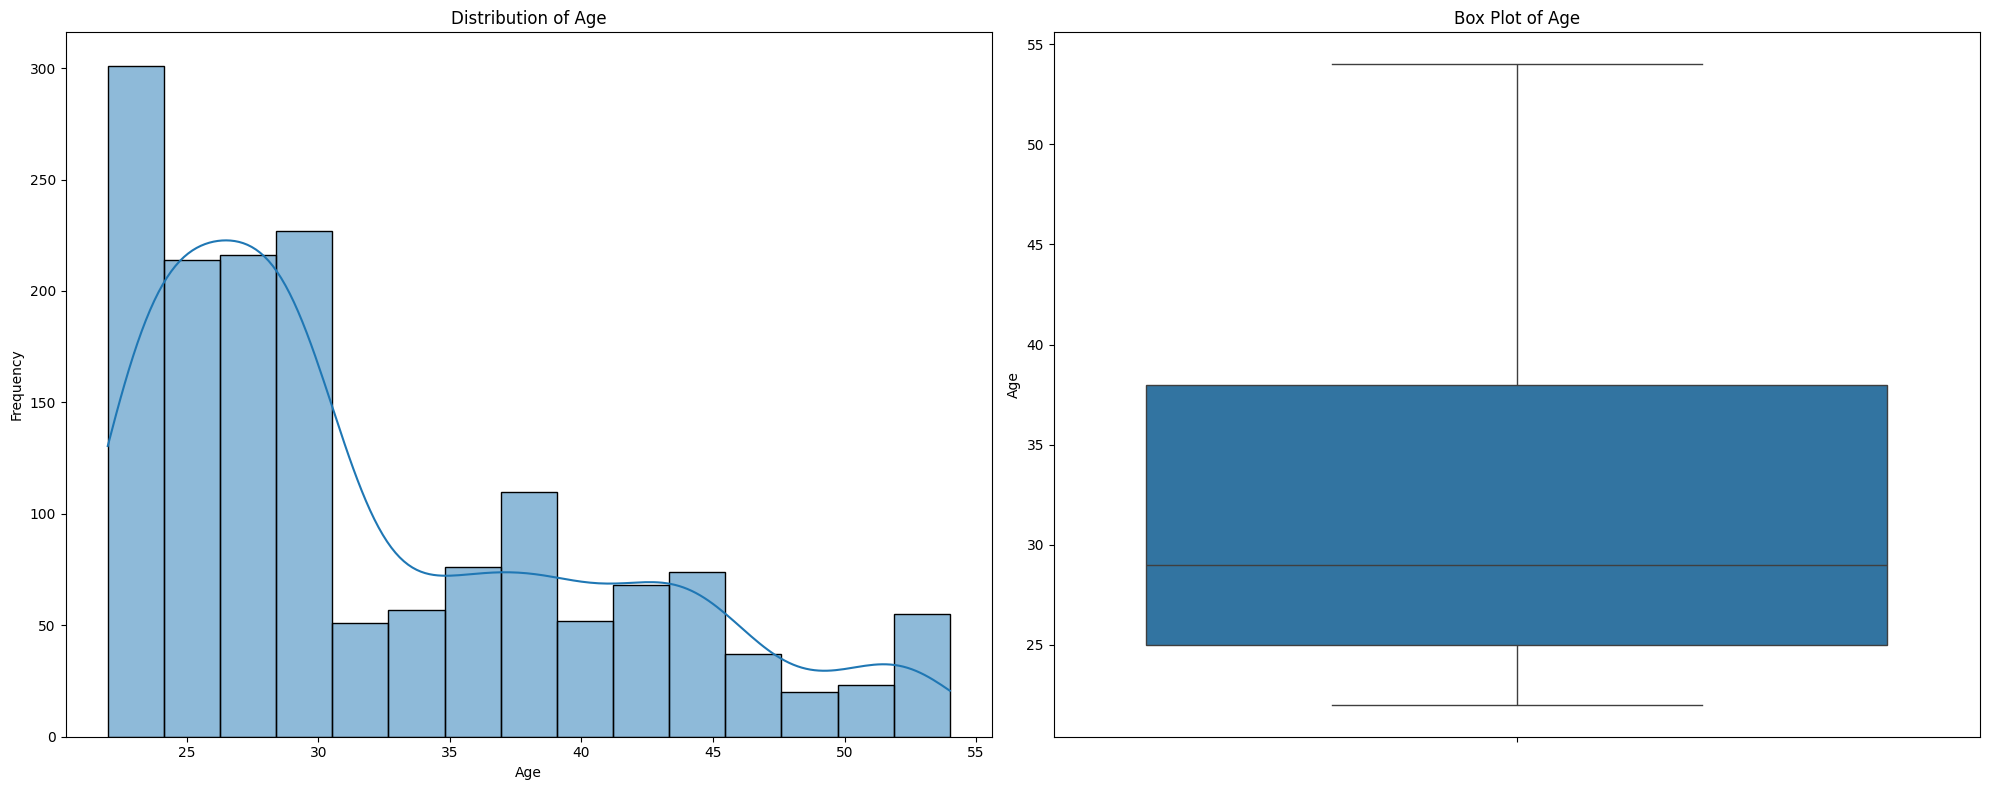


Descriptive statistics for Salary:
count     1581.000000
mean     60392.220114
std      14674.825044
min      30000.000000
25%      51900.000000
50%      59500.000000
75%      71800.000000
max      99300.000000
Name: Salary, dtype: float64


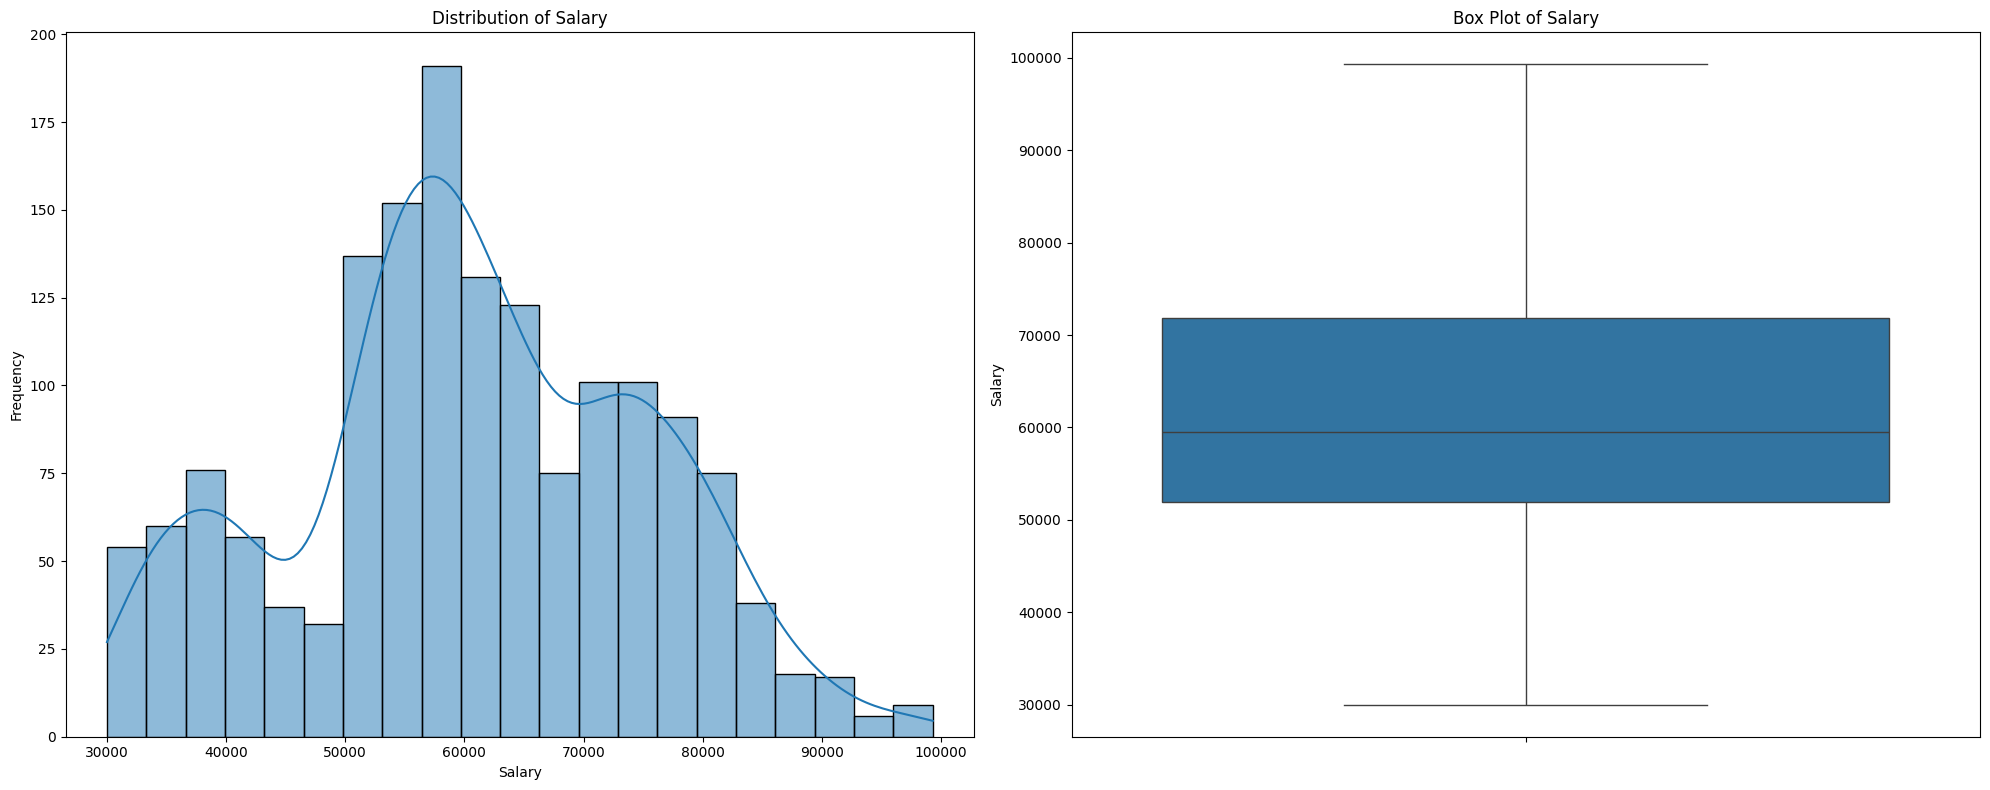


Descriptive statistics for Partner_salary:
count     1581.000000
mean     19202.466793
std      19526.571322
min          0.000000
25%          0.000000
50%      25100.000000
75%      38000.000000
max      80500.000000
Name: Partner_salary, dtype: float64


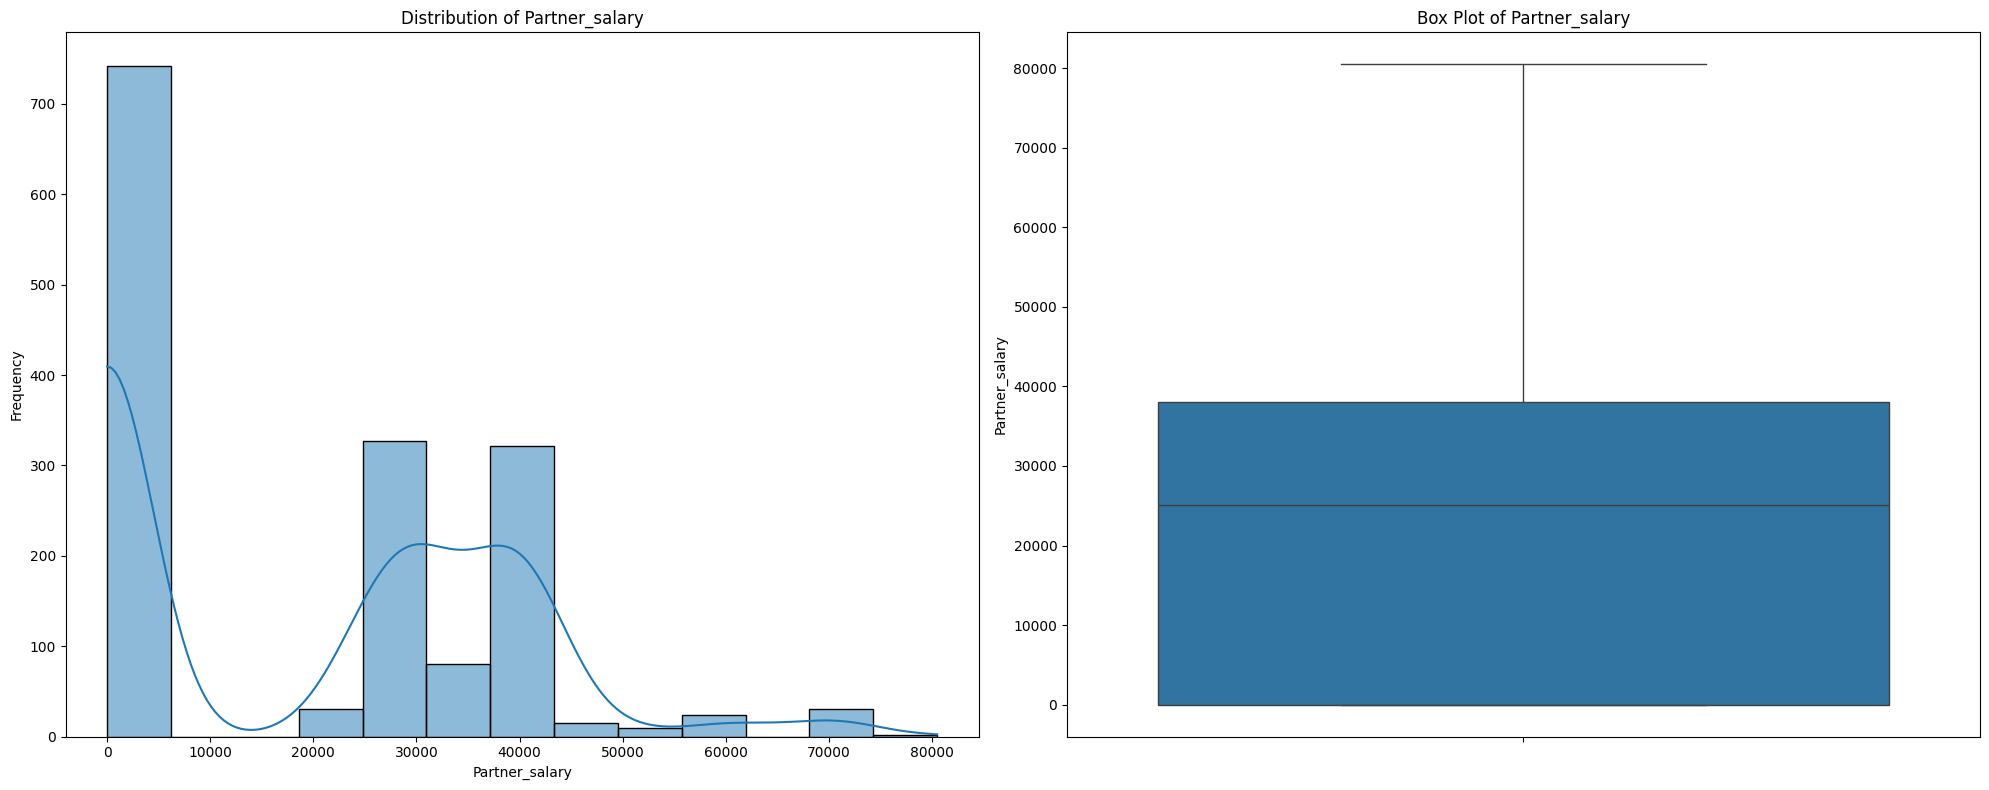


Descriptive statistics for Total_salary:
count      1581.000000
mean      79625.996205
std       25545.857768
min       30000.000000
25%       60500.000000
50%       78000.000000
75%       95900.000000
max      171000.000000
Name: Total_salary, dtype: float64


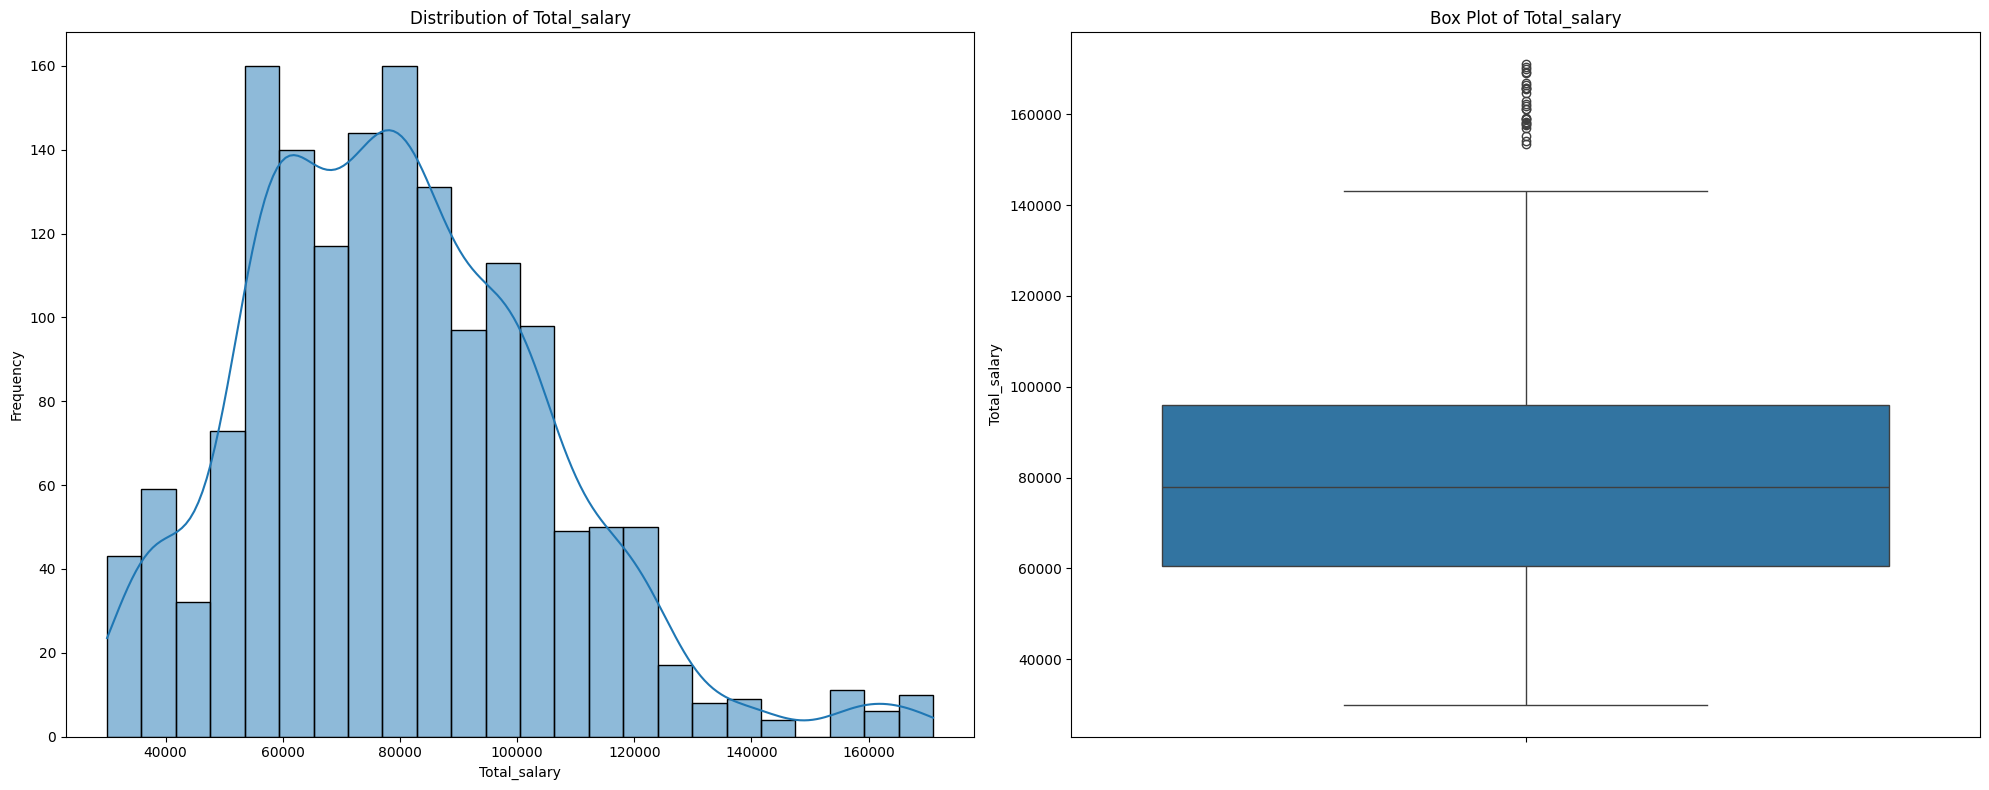


Descriptive statistics for Price:
count     1581.000000
mean     35597.722960
std      13633.636545
min      18000.000000
25%      25000.000000
50%      31000.000000
75%      47000.000000
max      70000.000000
Name: Price, dtype: float64


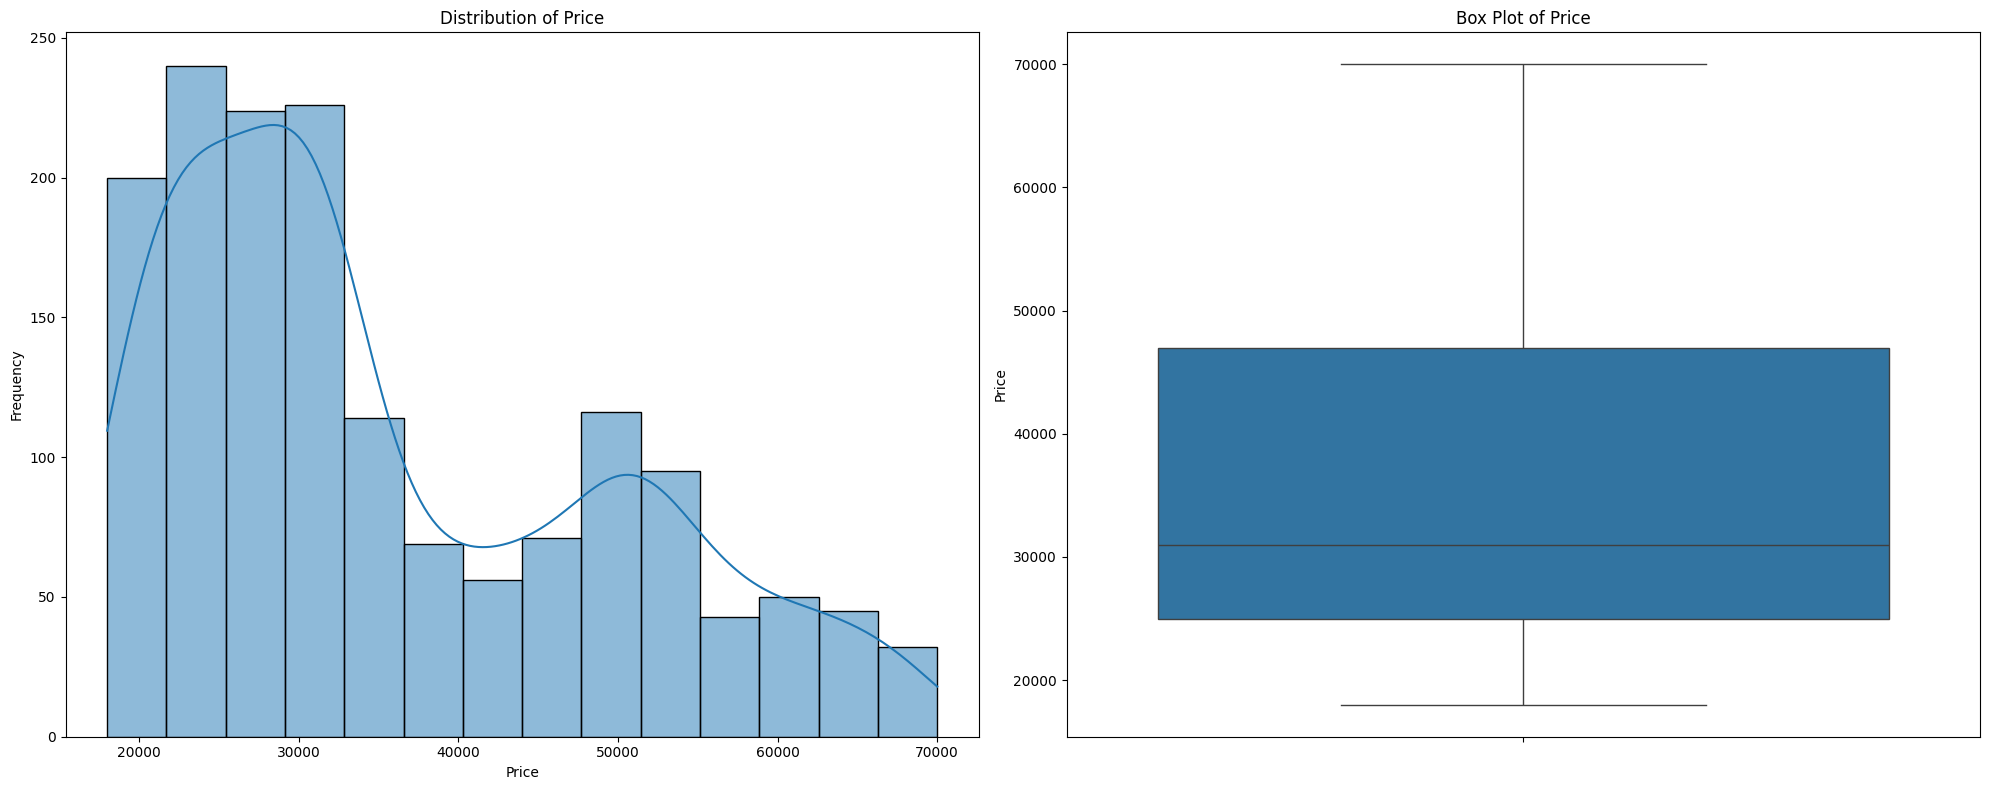

In [ ]:
numerical_cols = ['Age',  'Salary', 'Partner_salary', 'Total_salary', 'Price']

def numerical_univariate_analysis(df, column):
    print(f"\nDescriptive statistics for {column}:")
    print(df[column].describe())

    plt.figure(figsize=(20, 8))

    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

for col in numerical_cols:
    numerical_univariate_analysis(df, col)


## Univariate Analysis for Categorical Columns

1.Identify list of categorical columns ('Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan', 'House_loan', 'Partner_working', 'Make', 'No_of_Dependents')

2.Generate bar plots to visualize the frequency distribution of each category and display their value counts.


**Steps**:
To perform univariate analysis on the categorical columns:
1.Define a list of these columns.

2.Iterate through this list, displaying value counts

3.Generate a bar plot for each column to visualize its frequency distribution.




--- Analyzing Categorical Column: Gender ---
Value Counts for Gender:
Gender
Male         1199
Female        329
NOT Known      53
Name: count, dtype: int64


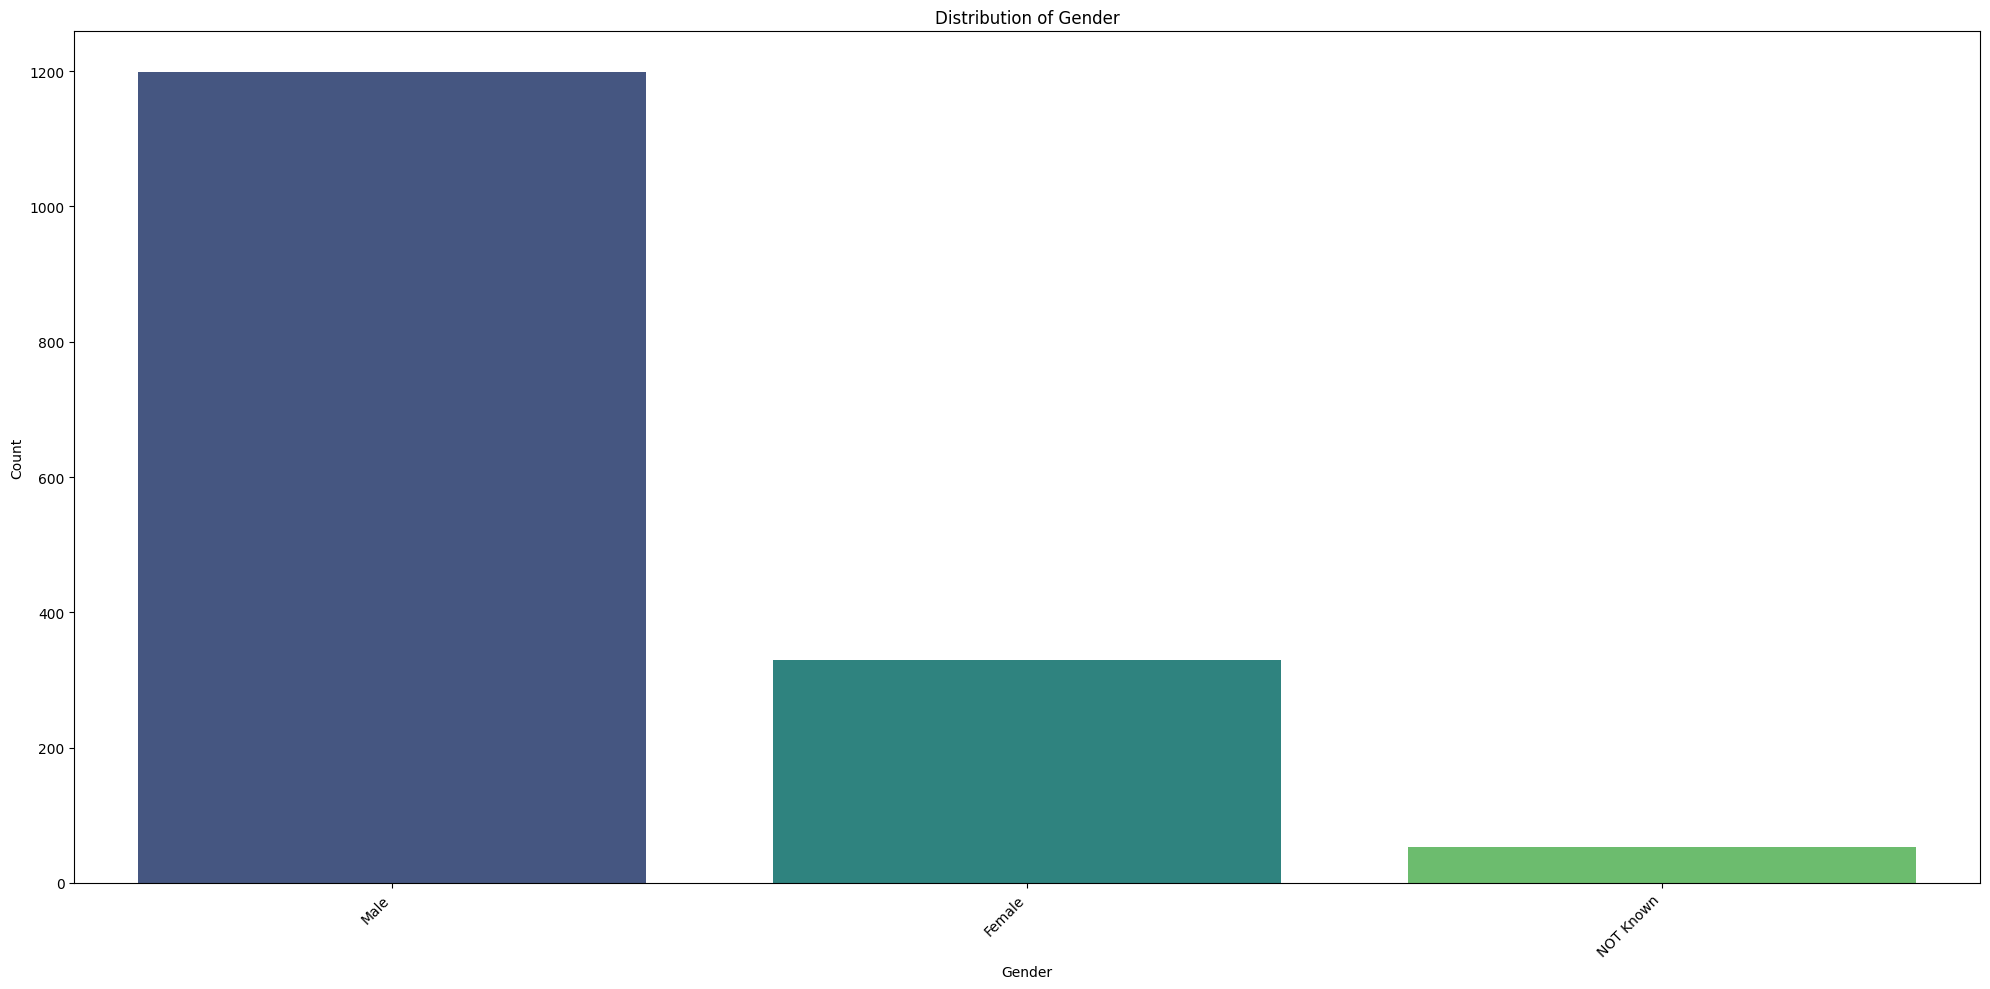


--- Analyzing Categorical Column: Profession ---
Value Counts for Profession:
Profession
Salaried    896
Business    685
Name: count, dtype: int64


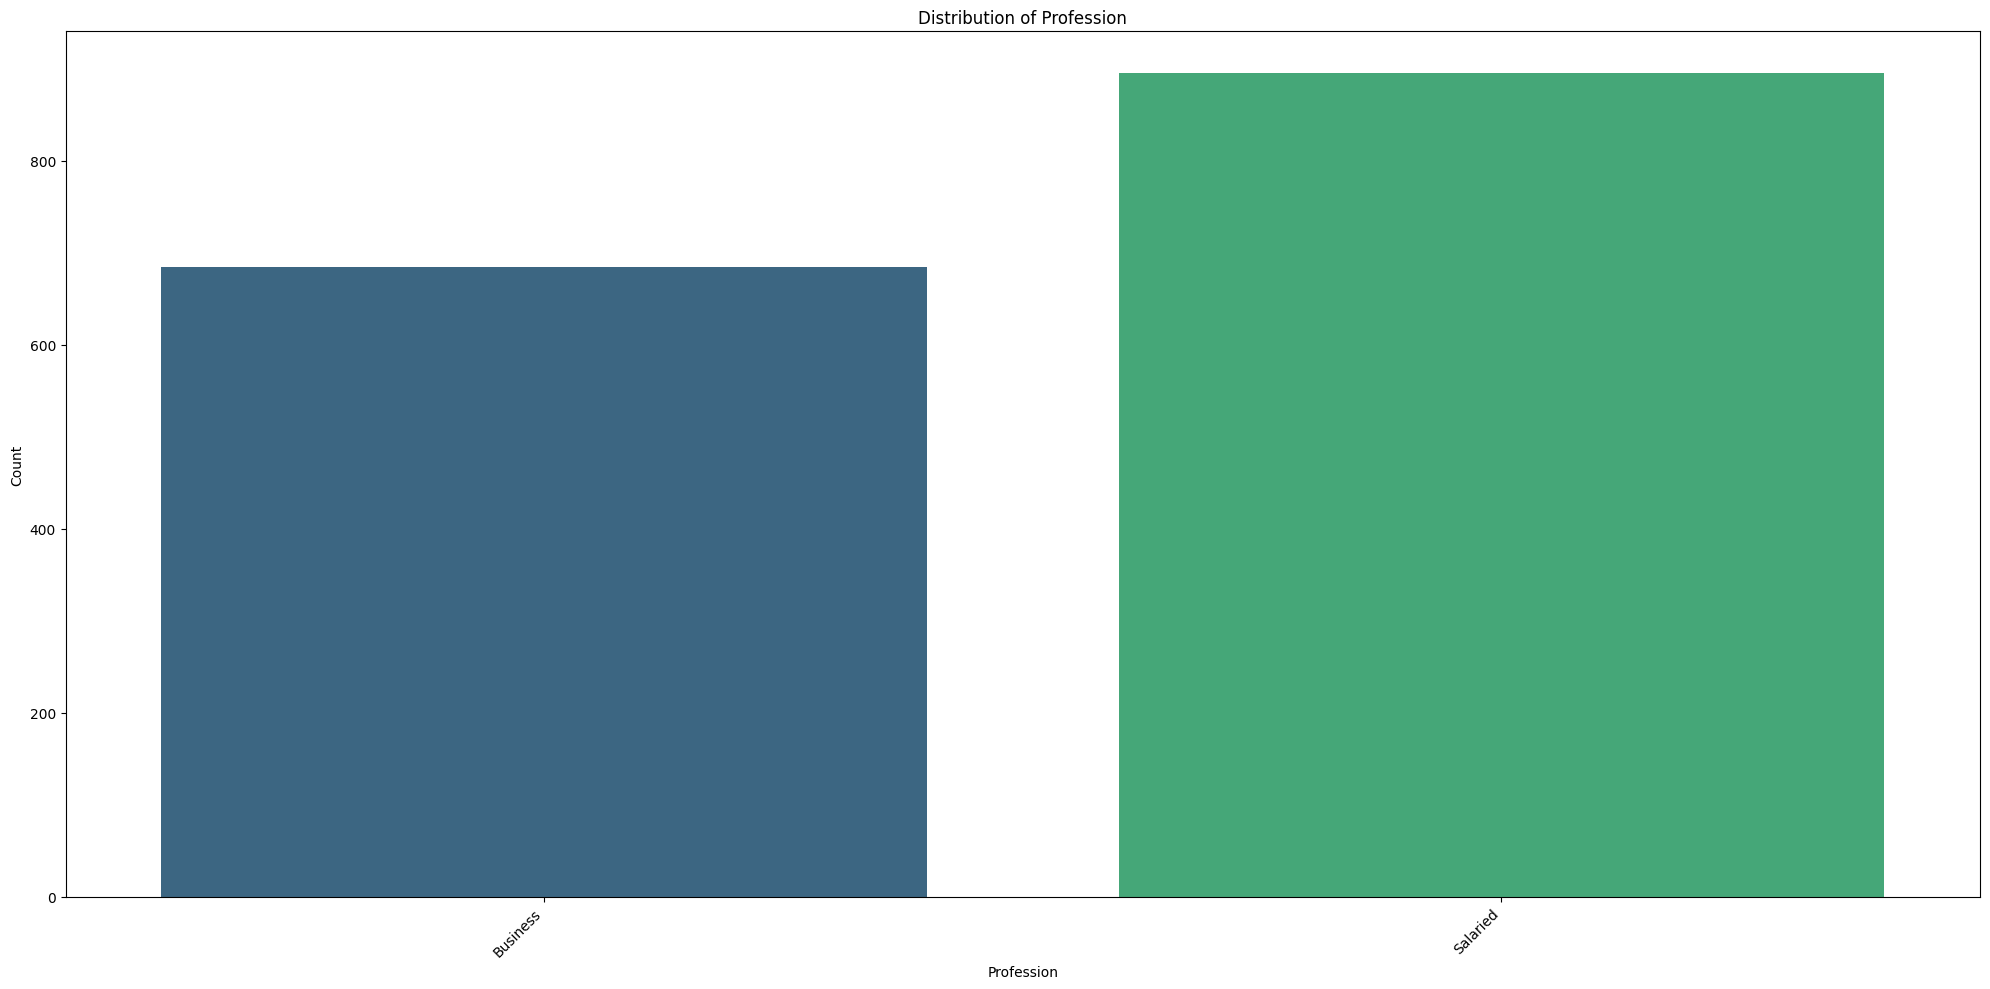


--- Analyzing Categorical Column: Marital_status ---
Value Counts for Marital_status:
Marital_status
Married    1443
Single      138
Name: count, dtype: int64


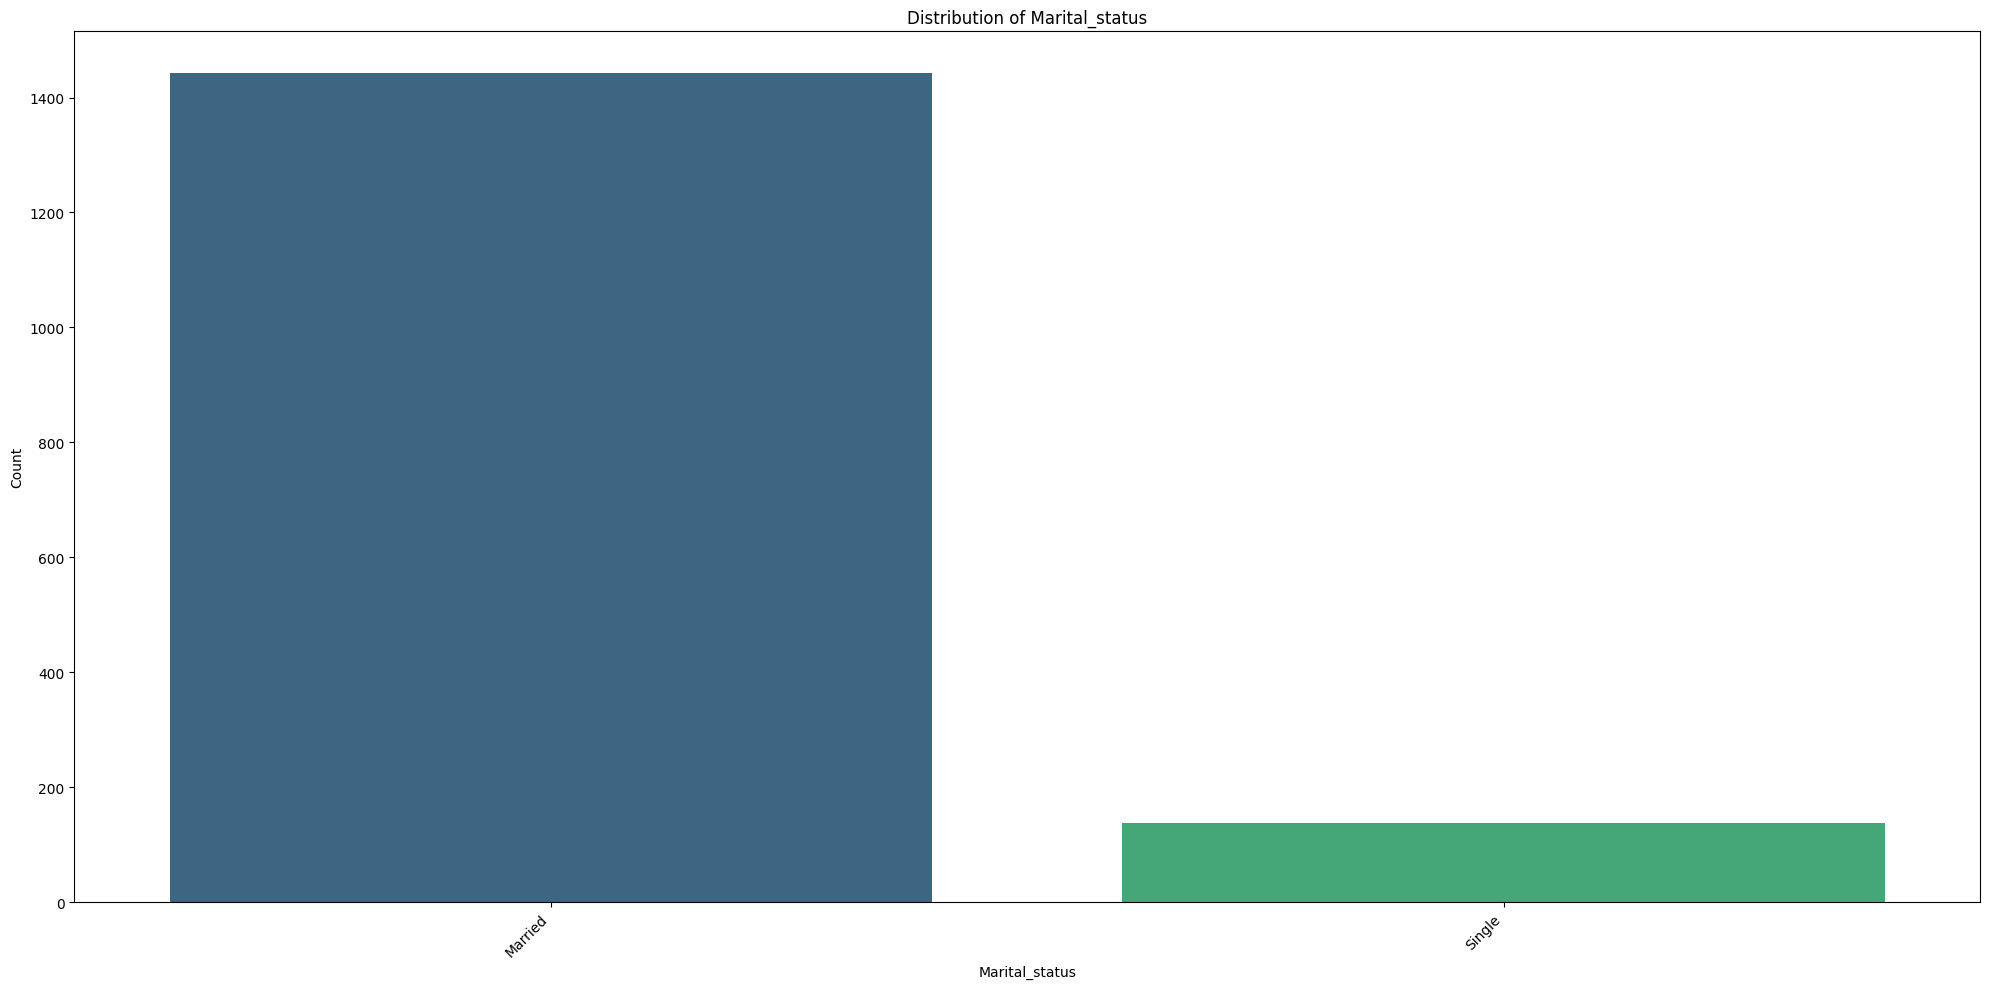


--- Analyzing Categorical Column: Education ---
Value Counts for Education:
Education
Post Graduate    985
Graduate         596
Name: count, dtype: int64


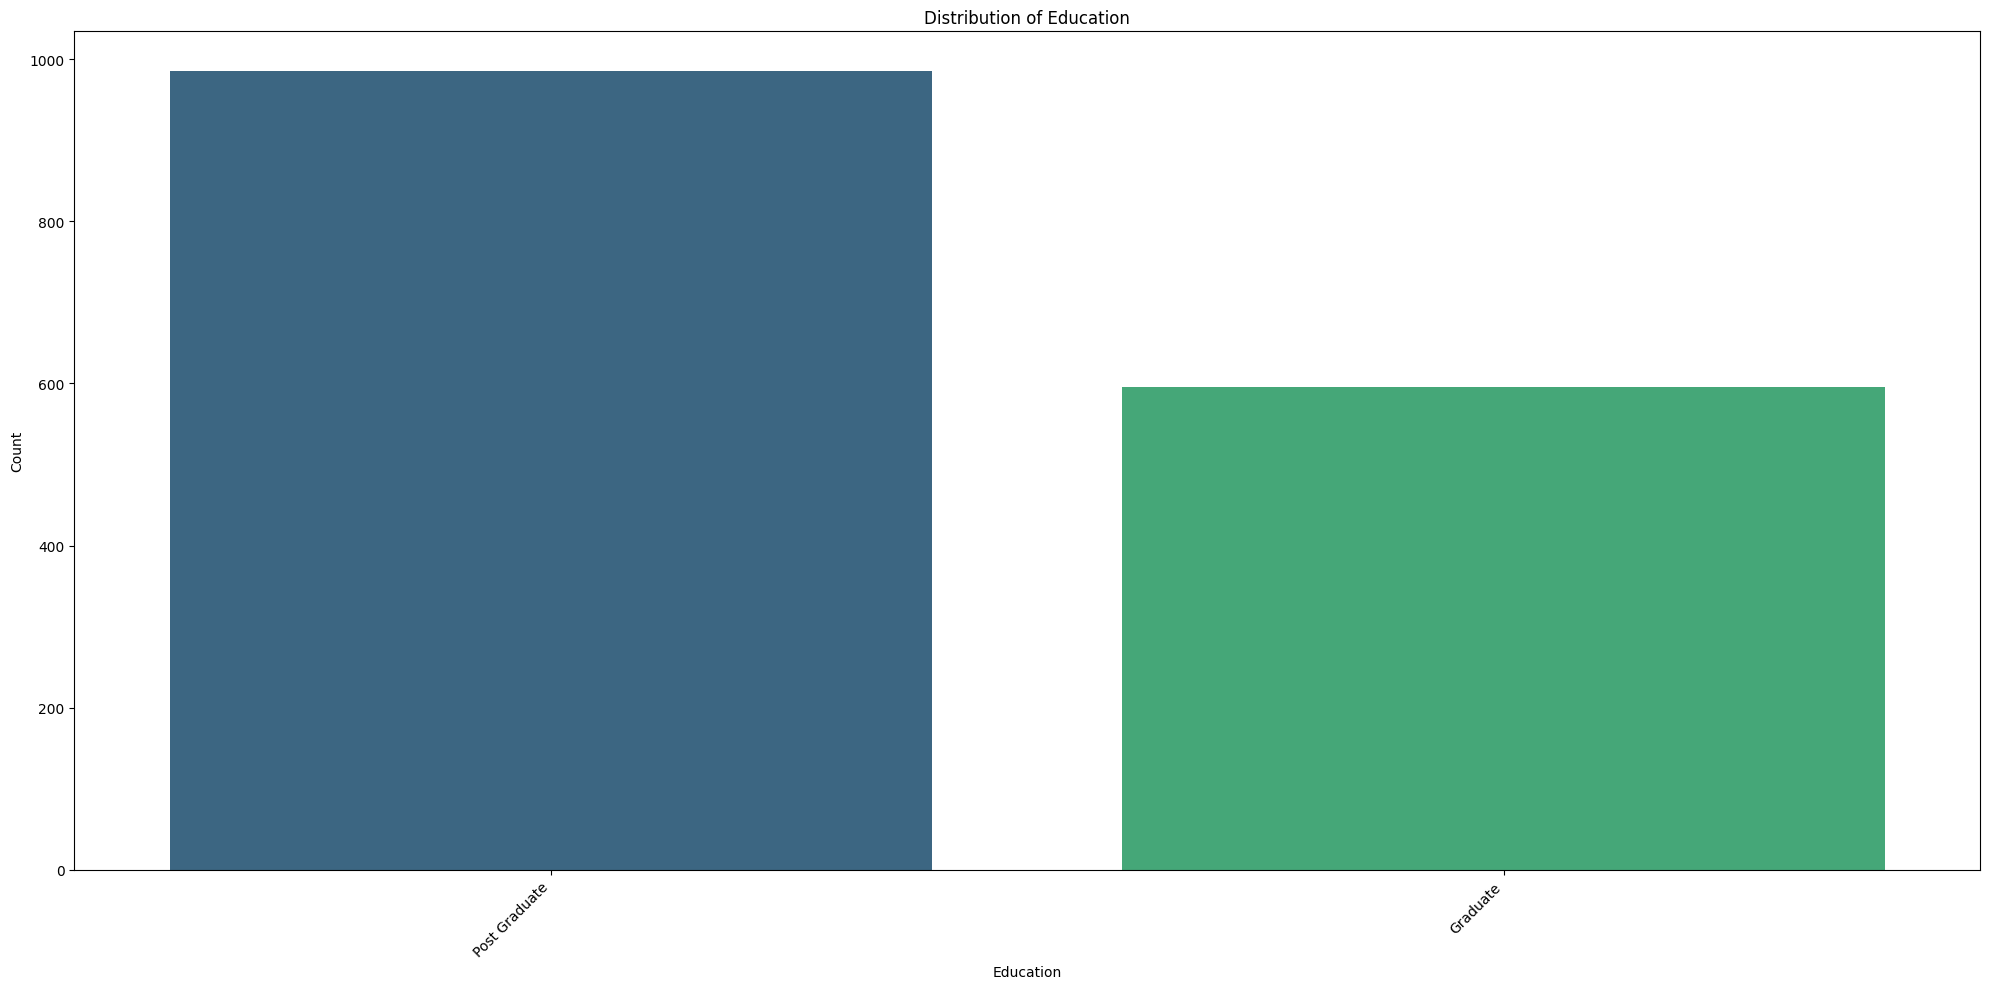


--- Analyzing Categorical Column: Personal_loan ---
Value Counts for Personal_loan:
Personal_loan
Yes    792
No     789
Name: count, dtype: int64


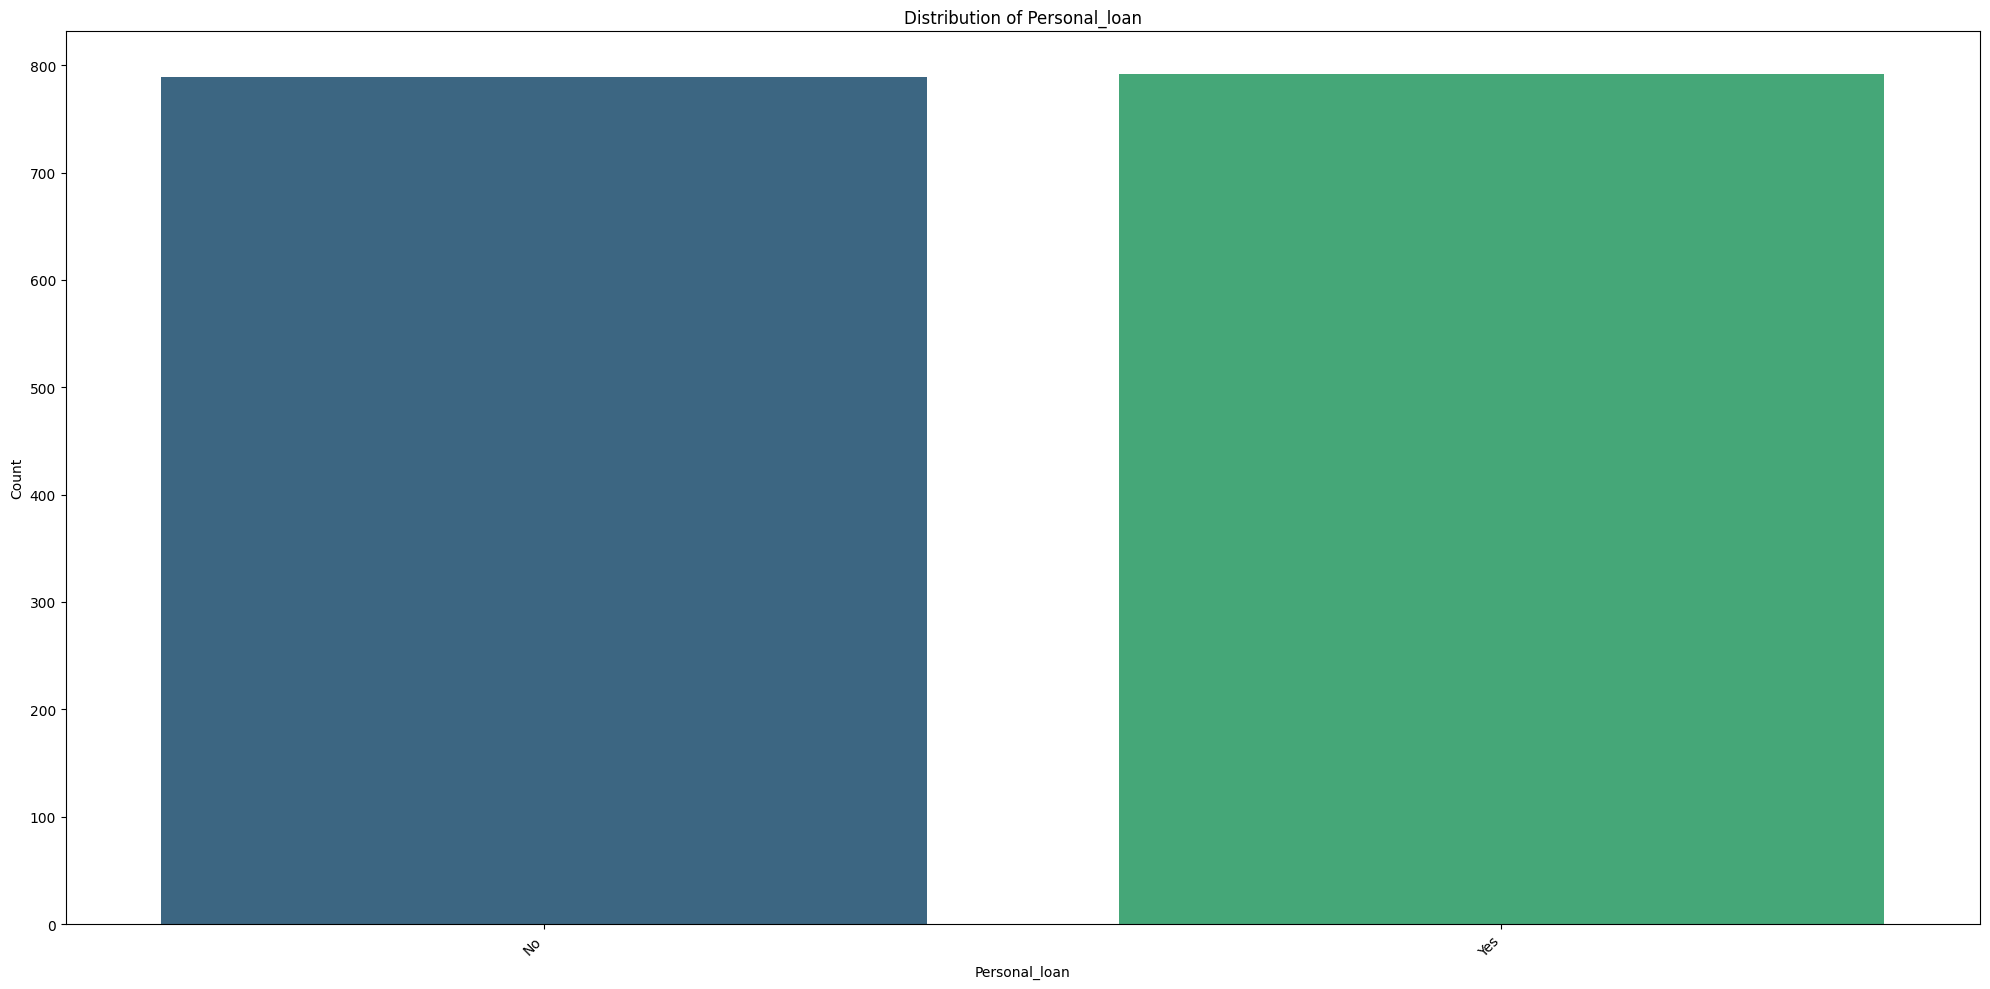


--- Analyzing Categorical Column: House_loan ---
Value Counts for House_loan:
House_loan
No     1054
Yes     527
Name: count, dtype: int64


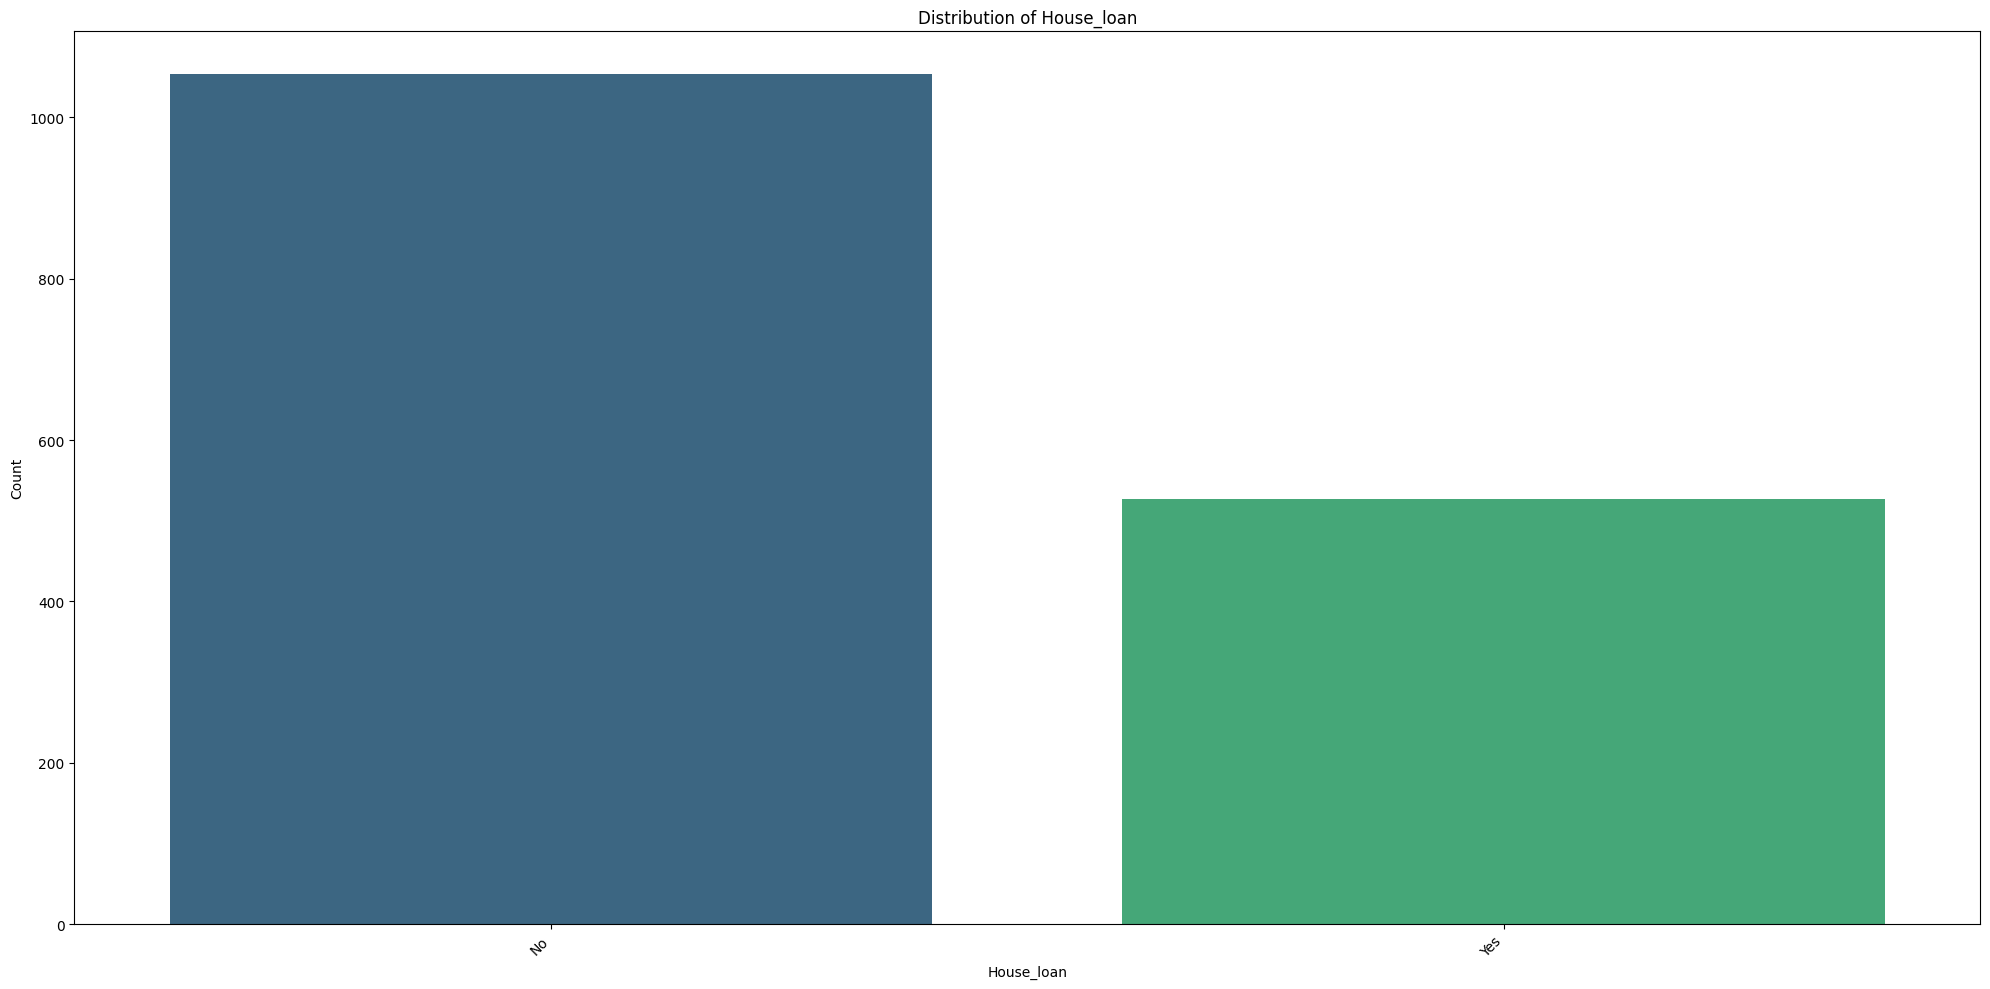


--- Analyzing Categorical Column: Partner_working ---
Value Counts for Partner_working:
Partner_working
Yes    868
No     713
Name: count, dtype: int64


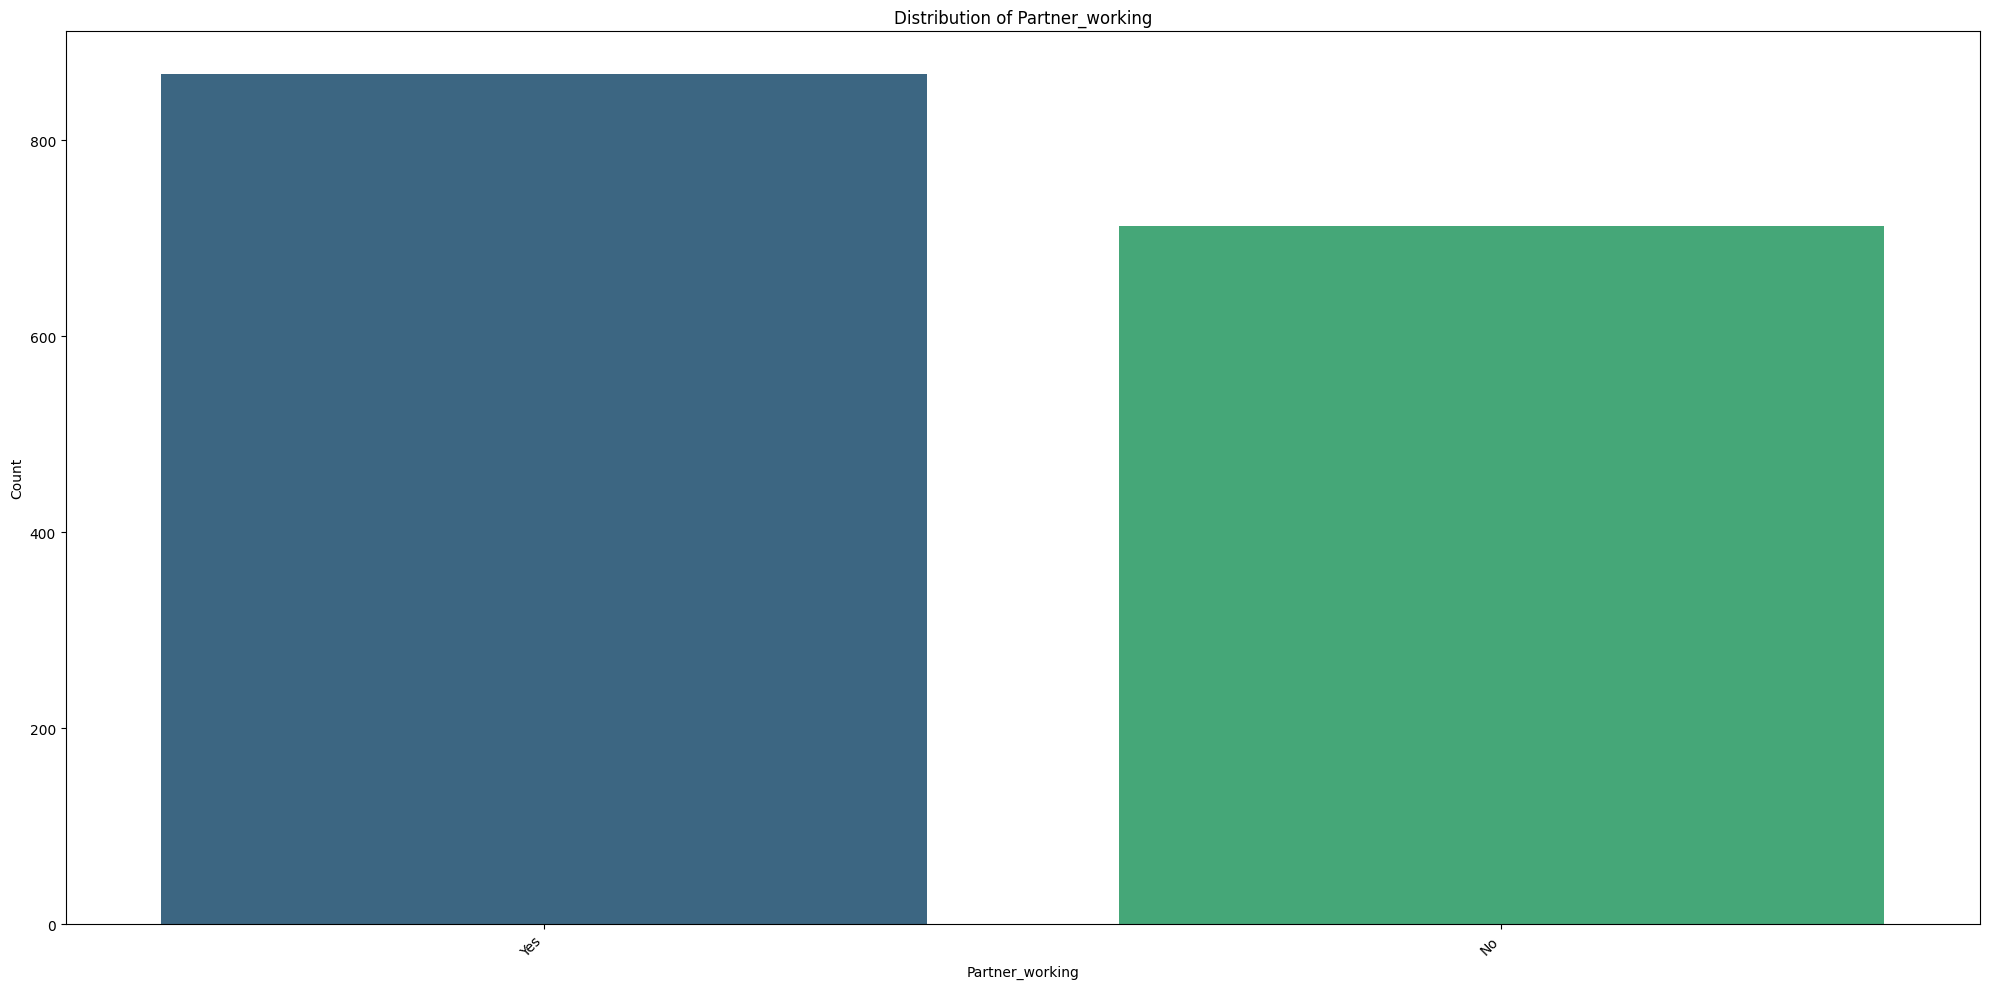


--- Analyzing Categorical Column: Make ---
Value Counts for Make:
Make
Sedan        702
Hatchback    582
SUV          297
Name: count, dtype: int64


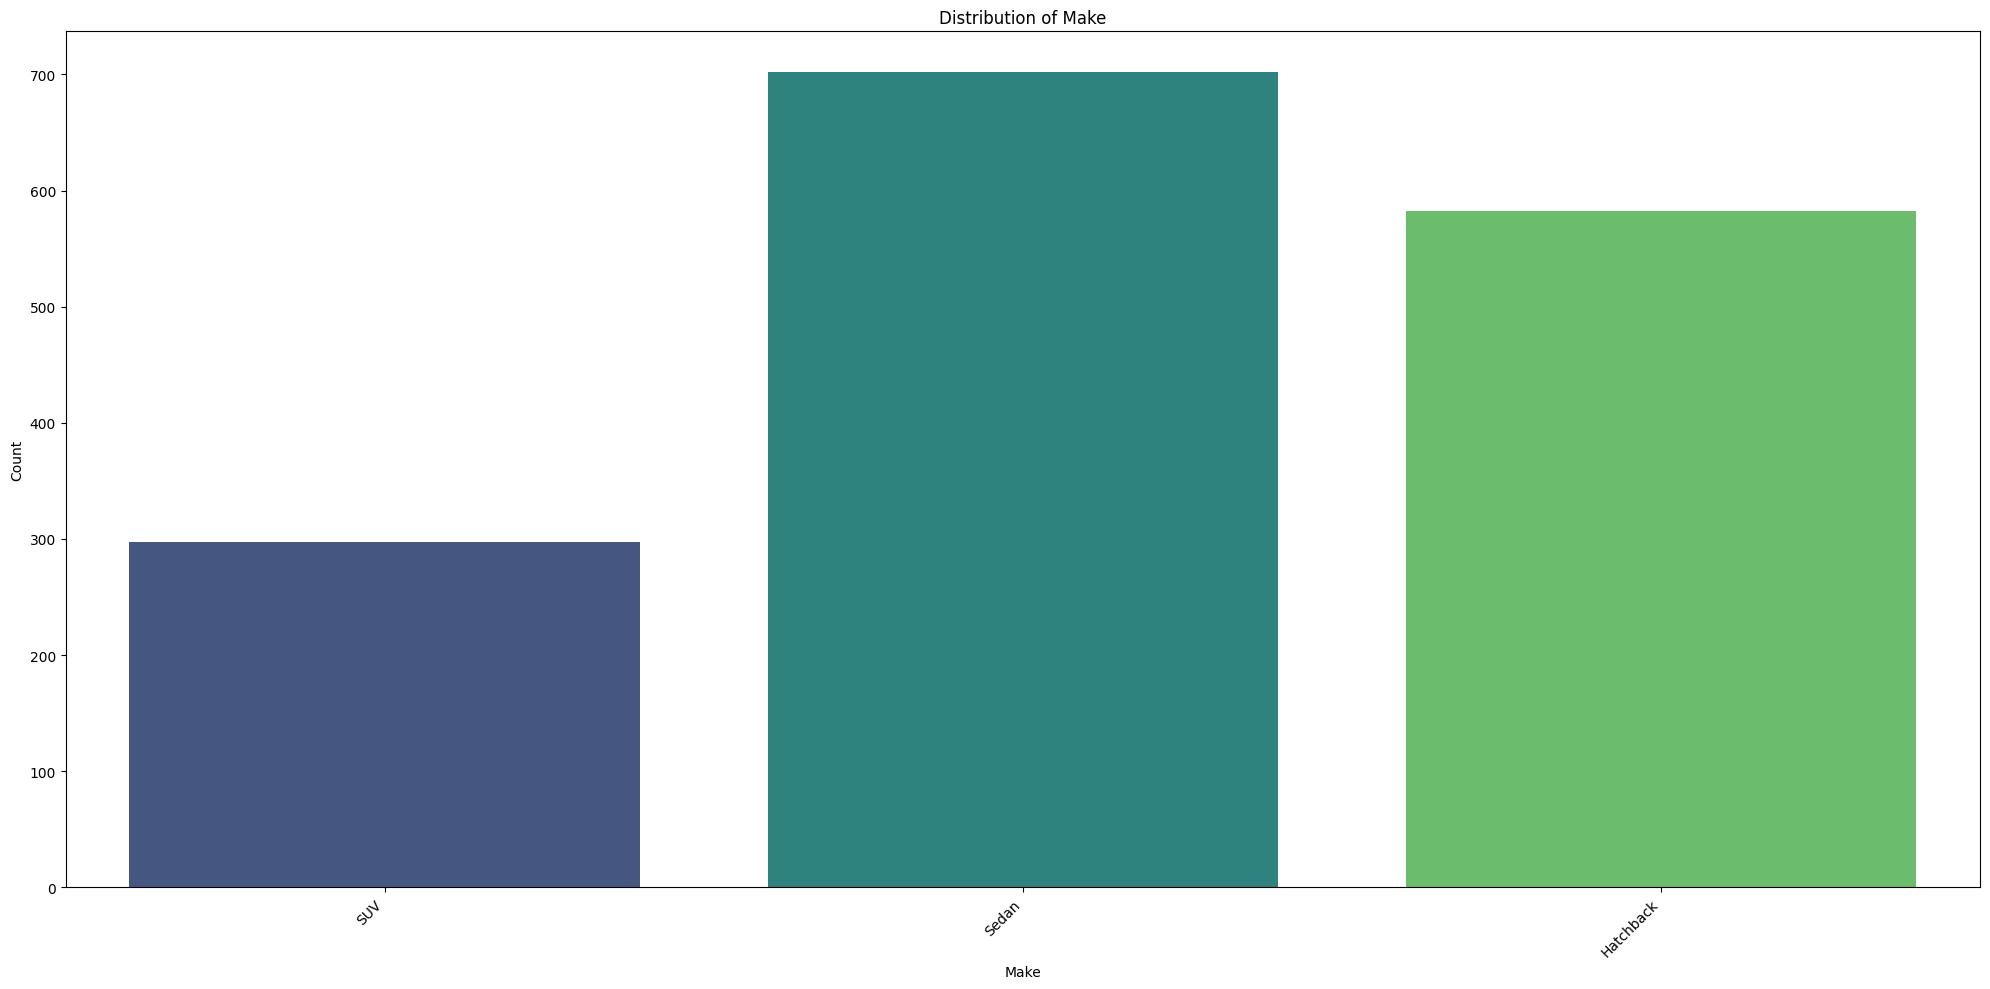


--- Analyzing Categorical Column: No_of_Dependents ---
Value Counts for No_of_Dependents:
No_of_Dependents
3    557
2    557
1    229
4    218
0     20
Name: count, dtype: int64


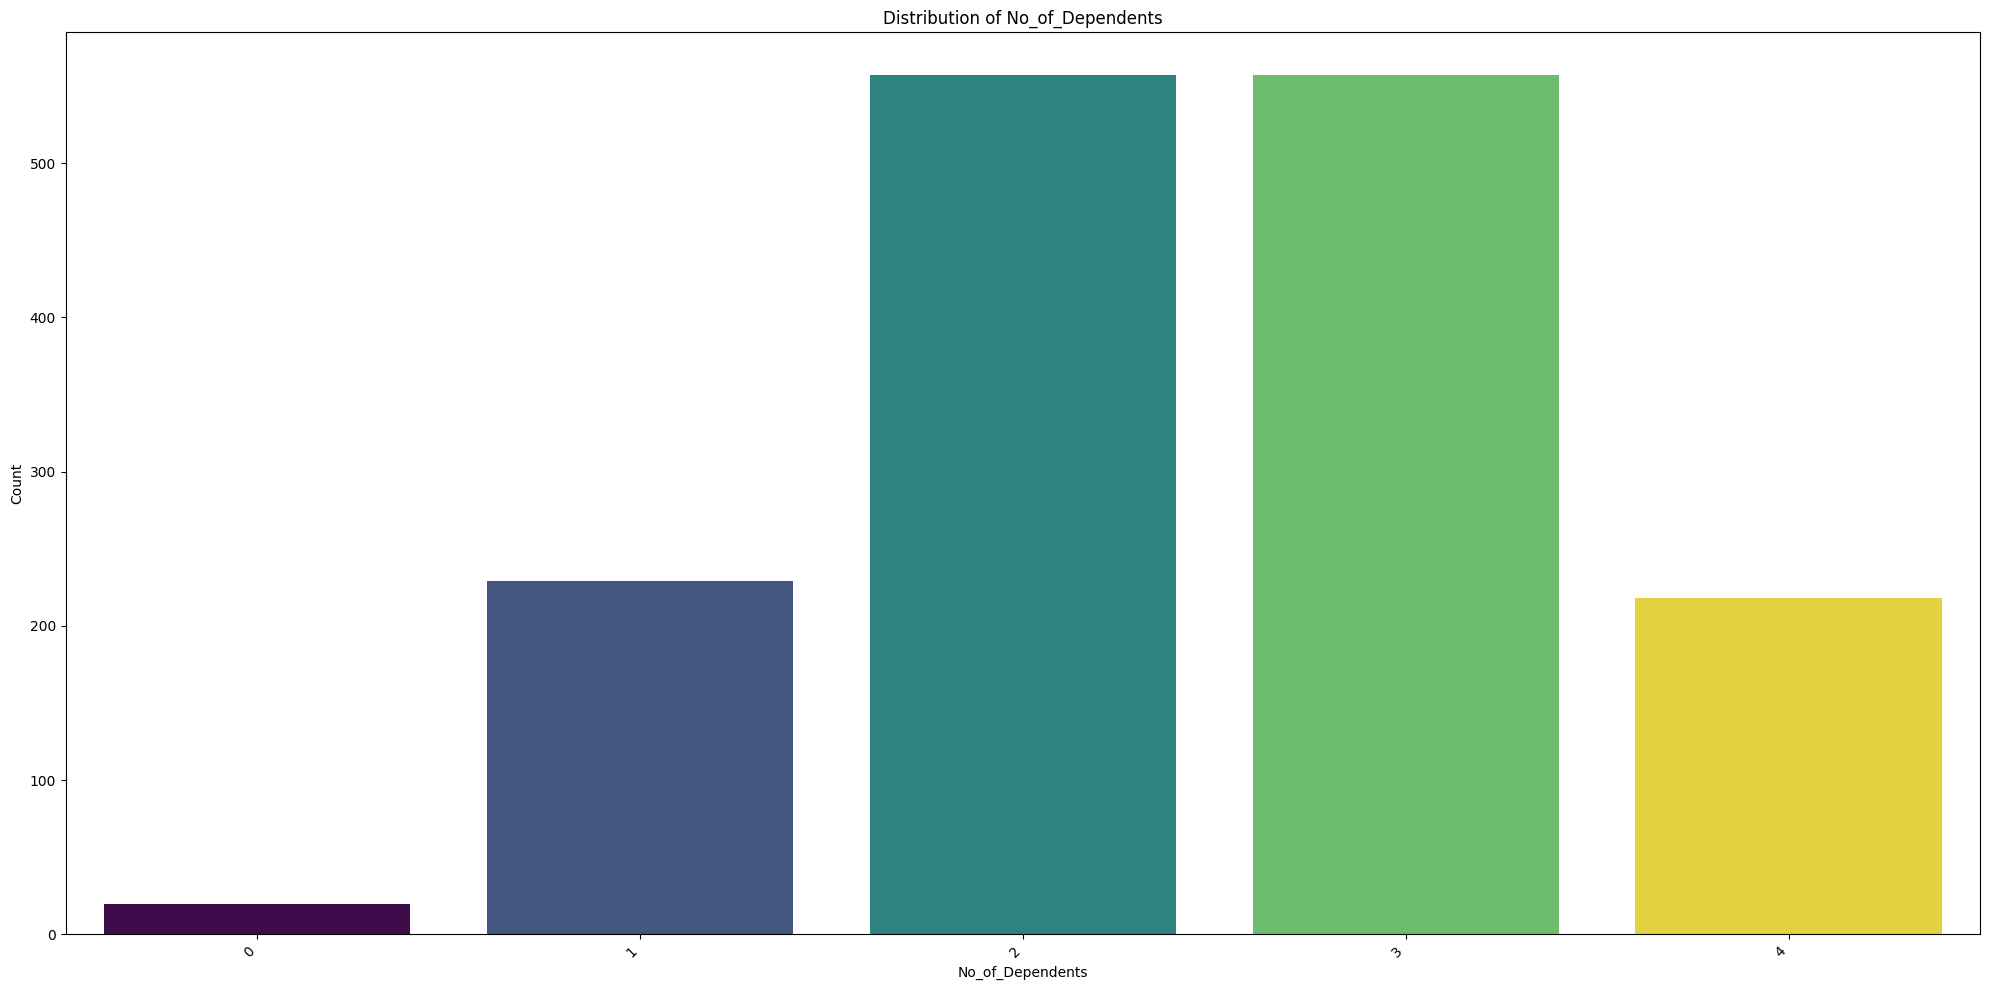

In [ ]:
categorical_cols = ['Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan', 'House_loan', 'Partner_working', 'Make', 'No_of_Dependents']

for col in categorical_cols:
    print(f"\n--- Analyzing Categorical Column: {col} ---")

    # Display value counts
    print(f"Value Counts for {col}:")
    print(df[col].value_counts())

    # Create a bar plot
    plt.figure(figsize=(20, 10))
    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Summary of Numerical Column Insights

Based on the descriptive statistics, histograms, and box plots for the numerical columns, here are the consolidated observations:

### Age
*   **Distribution Shape**: The histogram shows a right-skewed distribution, indicating a higher concentration of younger individuals. The peak is around 25-30 years.
*   **Central Tendency**: The mean age is approximately 31.92 years, and the median is 29.0 years, consistent with the right-skewness.
*   **Spread**: Ages range from 22 to 54 years. The interquartile range (IQR) is from 25.0 to 38.0 years.
*   **Outliers**: The box plot shows no significant outliers, but the upper whisker extends considerably, indicating a few older individuals.

### No_of_Dependents
*   **Distribution Shape**: This column is highly right-skewed, with most individuals having 2 or 3 dependents. The distribution is discrete.
*   **Central Tendency**: The median is 2.0.
*   **Spread**: The number of dependents ranges from 0 to 4. The IQR is from 2.0 to 3.0.
*   **Outliers**: The box plot suggests no significant outliers, as the maximum value is 4 and the minimum is 0, which are within typical ranges given the discrete nature.

### Salary
*   **Distribution Shape**: The histogram for 'Salary' appears to be somewhat symmetrically distributed, but with a slight left-skew. There are several peaks, suggesting multiple salary groups.
*   **Central Tendency**: The mean salary is approximately 60,392.22, and the median is 59,500.0. These values are close, reinforcing a relatively symmetric distribution.
*   **Spread**: Salaries range from 30,000 to 99,300. The IQR is from 51,900.0 to 71,800.0.
*   **Outliers**: The box plot indicates no significant outliers. The data appears to be well-contained within the whiskers.

### Partner_salary
*   **Distribution Shape**: This column is heavily right-skewed, with a large concentration at 0 (due to non-working partners) and then a tail extending to higher values. It's essentially a bimodal or multimodal distribution if we consider the non-zero salaries.
*   **Central Tendency**: The mean partner salary is approximately 19,202.47, and the median is 25,100.0 (after imputation, the original median for working partners was 32900). The significant difference between mean and median highlights the skewness and the presence of 0s.
*   **Spread**: Partner salaries range from 0 to 80,500. The IQR is from 0 to 38,000.
*   **Outliers**: The box plot clearly shows a significant number of outliers on the higher end of partner salaries, indicating a few partners earn considerably more.

### Total_salary
*   **Distribution Shape**: The histogram for 'Total_salary' is also right-skewed, although less pronounced than 'Partner_salary'. It generally follows the combined patterns of individual and partner salaries.
*   **Central Tendency**: The mean total salary is approximately 79,625.99, and the median is 78,000.0.
*   **Spread**: Total salaries range from 30,000 to 171,000. The IQR is from 60,500.0 to 95,900.0.
*   **Outliers**: The box plot shows several outliers on the higher end, consistent with the right-skewness, suggesting some households have very high combined incomes.

### Price
*   **Distribution Shape**: The histogram for 'Price' appears to be somewhat uniformly distributed across its range, perhaps with a slight right-skew. There isn't a strong central peak.
*   **Central Tendency**: The mean price is approximately 35,597.72, and the median is 31,000.0.
*   **Spread**: Prices range from 18,000 to 70,000. The IQR is from 25,000.0 to 47,000.0.
*   **Outliers**: The box plot indicates no clear outliers. The range of prices is broad, but the data points are within the expected variability.



## Summary of Categorical Column Insights

### Gender:
- **Distribution**: Predominantly Male. There are 1199 Male individuals compared to 329 Female individuals. Remaining 53 are NOT known in the given data
- **Imbalance**: A significant imbalance exists, with males outnumbering females.

### Profession:
- **Distribution**: The majority of individuals are 'Salaried' (896), followed by 'Business' (685).
- **Imbalance**: While Salaried individuals are more numerous, Business professionals represent a substantial portion, indicating two primary professional groups.

### Marital_status:
- **Distribution**: Overwhelmingly 'Married' (1443 individuals), with a much smaller group of 'Single' individuals (138).
- **Imbalance**: A strong imbalance towards married individuals is observed.

### Education:
- **Distribution**: 'Post Graduate' is the most common education level (985), followed by 'Graduate' (596).
- **Imbalance**: Post Graduates are significantly more represented than Graduates.

### Personal_loan:
- **Distribution**: The distribution between those with a personal loan ('Yes': 792) and those without ('No': 789) is almost evenly split.
- **Imbalance**: There is a balanced distribution, suggesting an almost equal likelihood of individuals having or not having a personal loan.

### House_loan:
- **Distribution**: A majority of individuals do not have a house loan ('No': 1054) compared to those who do ('Yes': 527).
- **Imbalance**: There are twice as many individuals without a house loan than with one.

### Partner_working:
- **Distribution**: The majority of individuals have a 'Yes' for 'Partner_working' (868), indicating their partner is employed, while 713 individuals have a 'No'.
- **Imbalance**: More individuals have working partners than not, but the difference is not as stark as in some other categories.

### Make:
- **Distribution**: 'Sedan' is the most popular car make (702), followed by 'Hatchback' (582), and then 'SUV' (297).
- **Imbalance**: Sedan and Hatchback are significantly more popular than SUVs, which represent the smallest segment.

### No_of_Dependents
- **Distribution**: This column is highly right-skewed, with most individuals having 2 or 3 dependents. The distribution is discrete.
- **Imbalance**: The maximum value is 4 and the minimum is 0, which are within typical ranges given the discrete nature.


## Summary:

### Data Analysis Key Findings

*   **Income Distributions**:
    *   'Partner\_salary' is heavily right-skewed with a large concentration at $0 and significant high-end outliers, indicating a bimodal nature likely due to partners not working or having very high incomes. The mean is approximately $19,202.47.
    *   'Total\_salary' is also right-skewed with several high-end outliers, with a mean of approximately $79,625.99, reflecting the influence of the 'Partner\_salary' distribution.
    *   'Salary' is relatively symmetric with a slight left-skew, having a mean of approximately $60,392.22 and no significant outliers.
*   **Demographic Skewness**:
    *   'Age' and 'No\_of\_Dependents' are right-skewed, indicating a younger population with most individuals having 2 or 3 dependents.
    *   'Gender' shows a significant imbalance with males  outnumbering females.
    *   'Marital\_status' is overwhelmingly 'Married' (1443 individuals) compared to 'Single' (138 individuals).
*   **Loan and Employment Status**:
    *   'Personal\_loan' distribution is almost evenly split between 'Yes' (792) and 'No' (789).
    *   There's a 2:1 imbalance for 'House\_loan', with more individuals not having a loan ('No': 1054) than having one ('Yes': 527).
    *   More individuals have working partners ('Yes': 868) than not ('No': 713), though the difference is not as stark as other categories.
*   **Education and Vehicle Preferences**:
    *   'Post Graduate' is the most common education level (985), followed by 'Graduate' (596).
    *   'Sedan' (702) and 'Hatchback' (582) are significantly more popular car makes than 'SUV' (297).

### Insights or Next Steps

*   The significant skewness and presence of outliers in income-related numerical features ('Partner\_salary', 'Total\_salary') suggest that these variables might require transformation, to mitigate the impact of extreme values.
*   The substantial imbalances observed in categorical features such as 'Gender', 'Marital\_status', and 'Education' indicate that these demographic factors could be strong drivers for customer segmentation or loan eligibility.


# Bivariate Analysis:


Visualize the correlation matrix for the numerical variables ('Age', 'Salary', 'Partner_salary', 'Total_salary', 'Price') using a heatmap to identify linear relationships between them, especially with 'Price'.

## Analyze Numerical Variable Correlations

Calculate and visualize the correlation matrix for all numerical variables ('Age', 'No_of_Dependents', 'Salary', 'Partner_salary', 'Total_salary', 'Price') using a heatmap. This step aims to identify linear relationships between numerical features, especially how other numerical features correlate with 'Price'.


1. Select the specified numerical columns
2. Calculate their correlation matrix
3. Generate a heatmap with annotations and a title to visualize these correlations



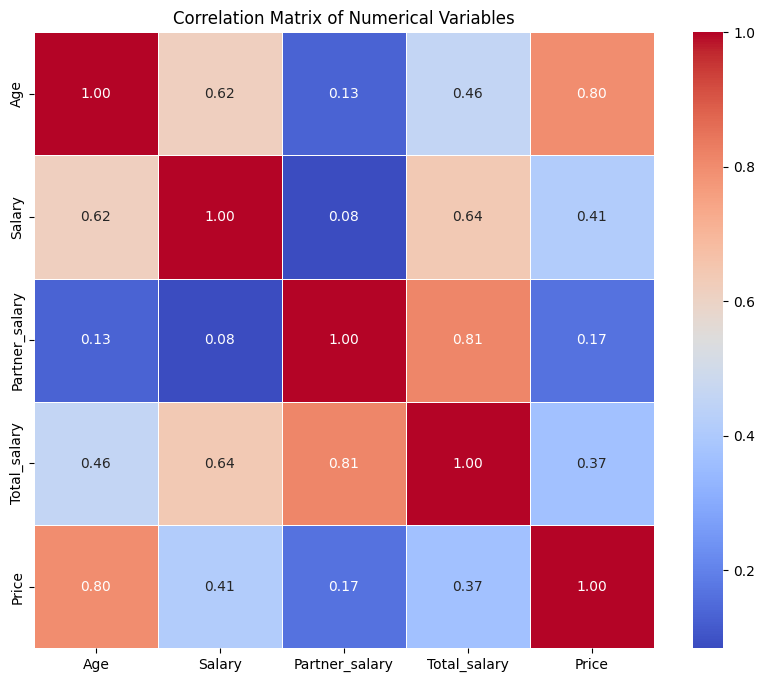

In [ ]:
numerical_cols_for_corr = ['Age', 'Salary', 'Partner_salary', 'Total_salary', 'Price']

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols_for_corr].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## Price Distribution by Car Make

Create a box plot to visualize the distribution of 'Price' for each 'Make' of the car. This will help understand if certain car types ('Sedan', 'Hatchback', 'SUV') are associated with certain price ranges.


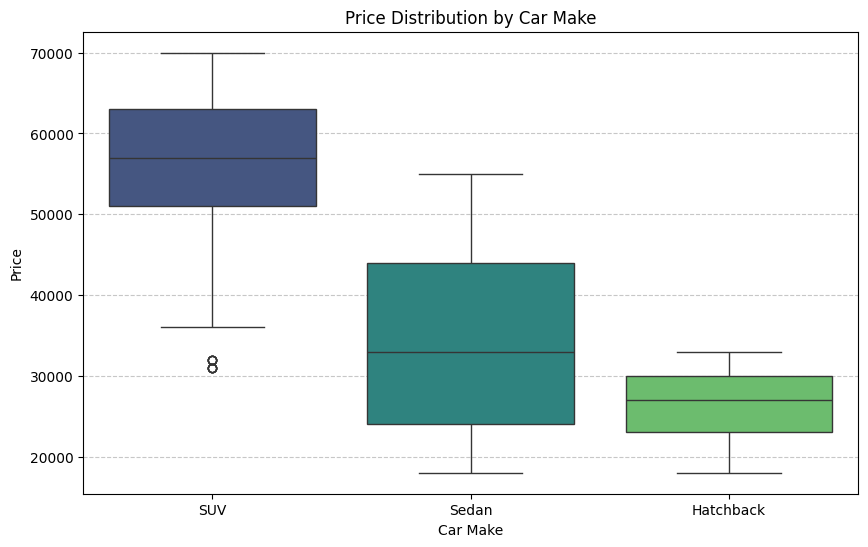

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Make', y='Price', hue='Make', palette='viridis', legend=False)
plt.title('Price Distribution by Car Make')
plt.xlabel('Car Make')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Price Distribution by Demographic and Financial Categories

Create box plots to analyze how 'Price' varies across different categories of 'Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan', 'House_loan', 'Partner_working' and 'No_of_Dependents'. This will reveal if specific customer segments tend to buy more expensive or cheaper cars.


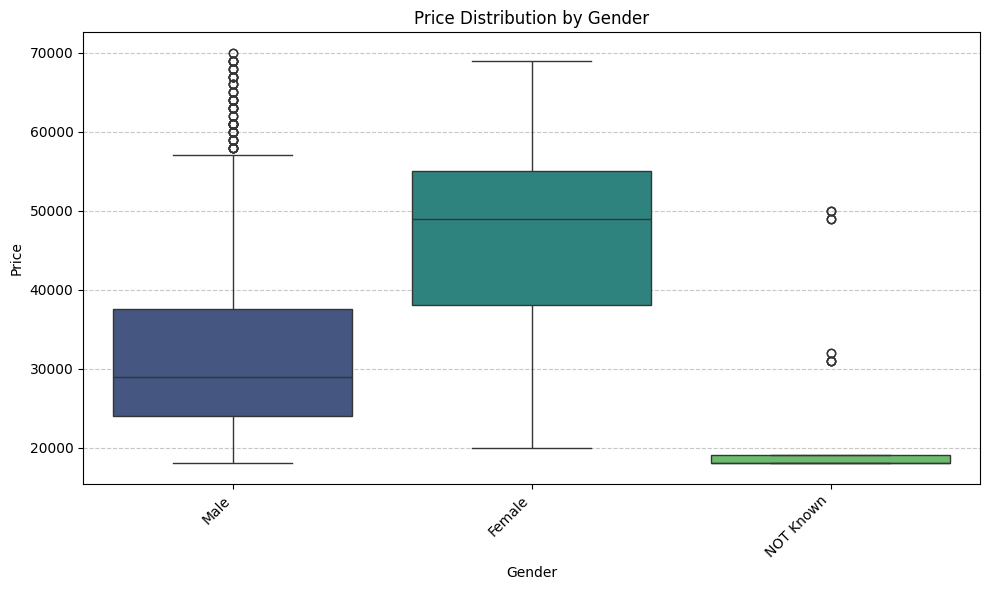

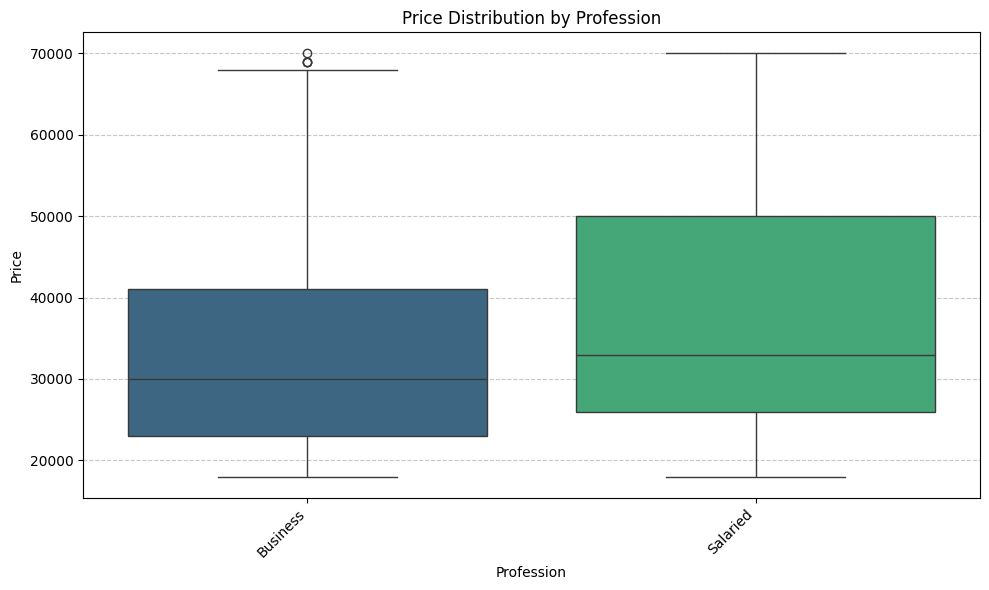

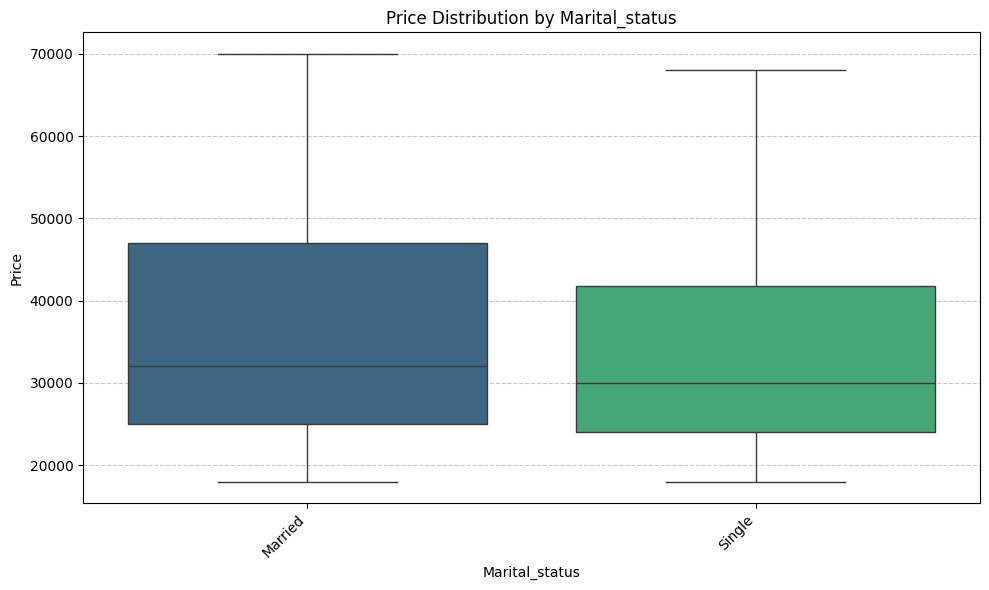

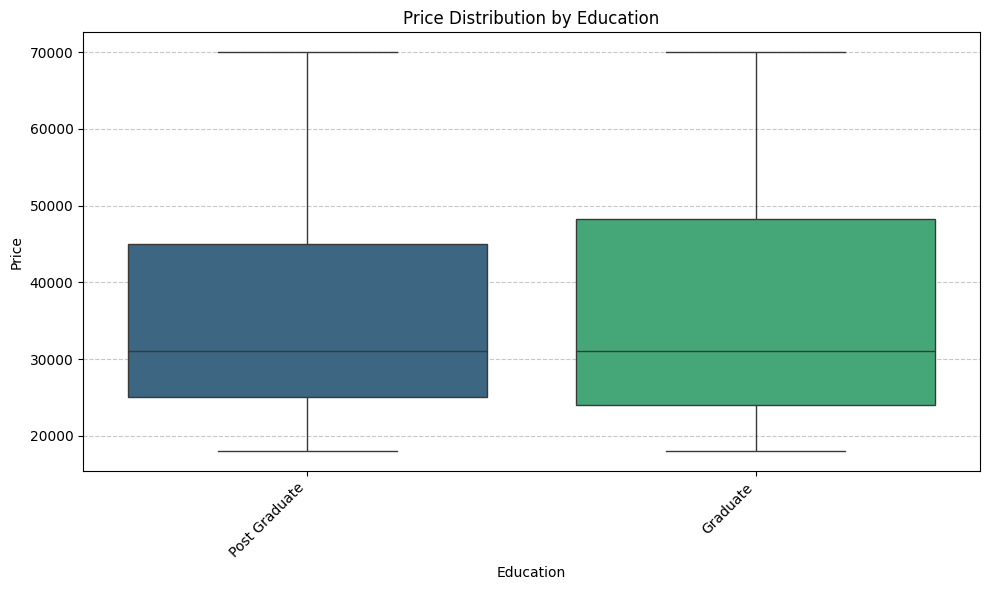

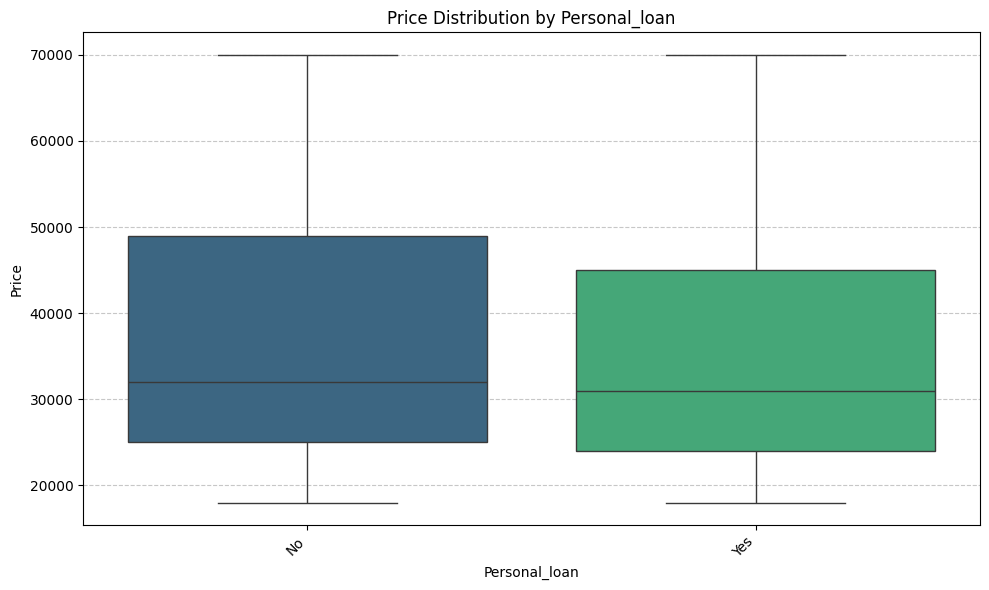

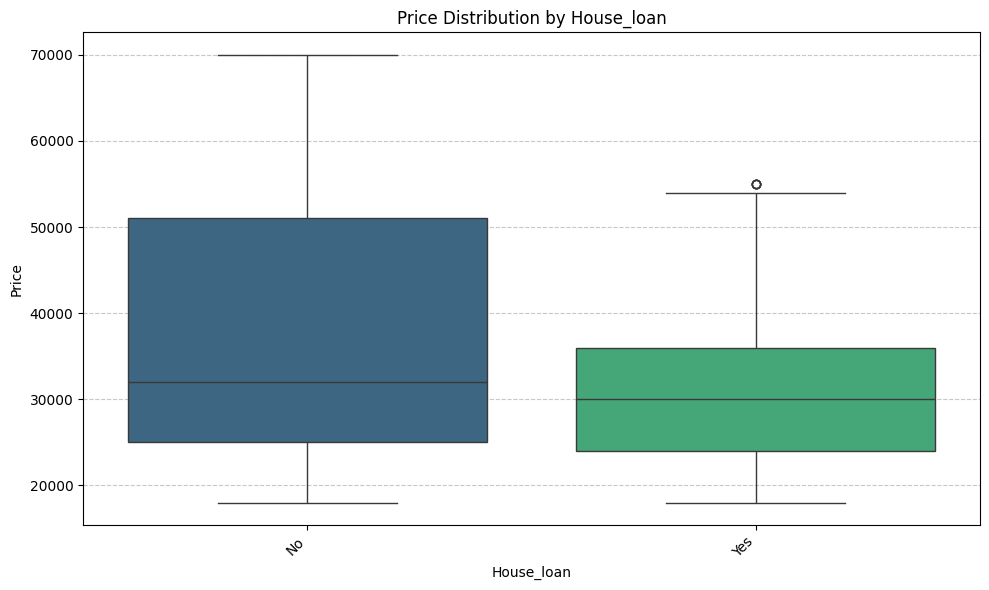

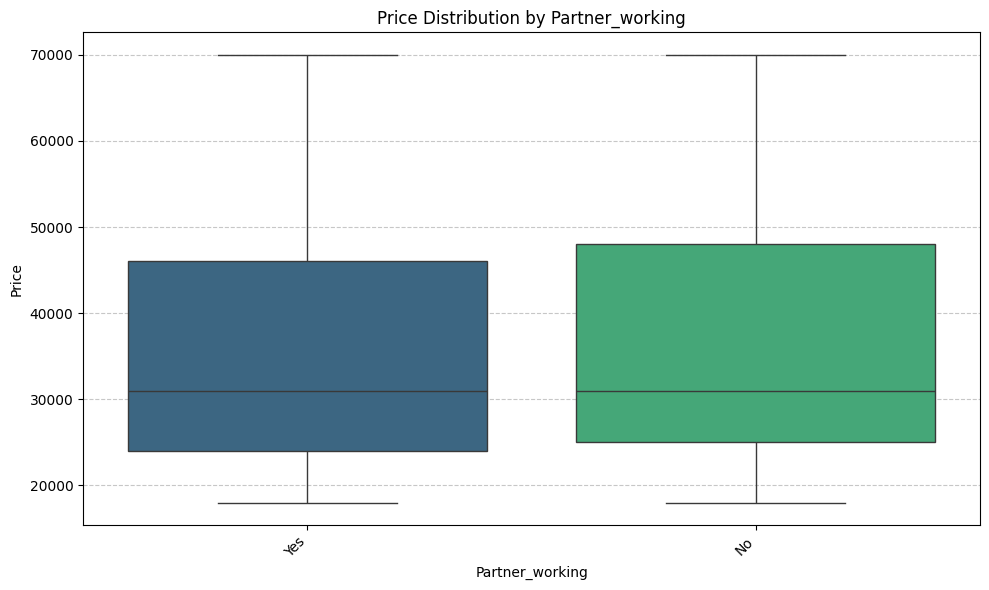

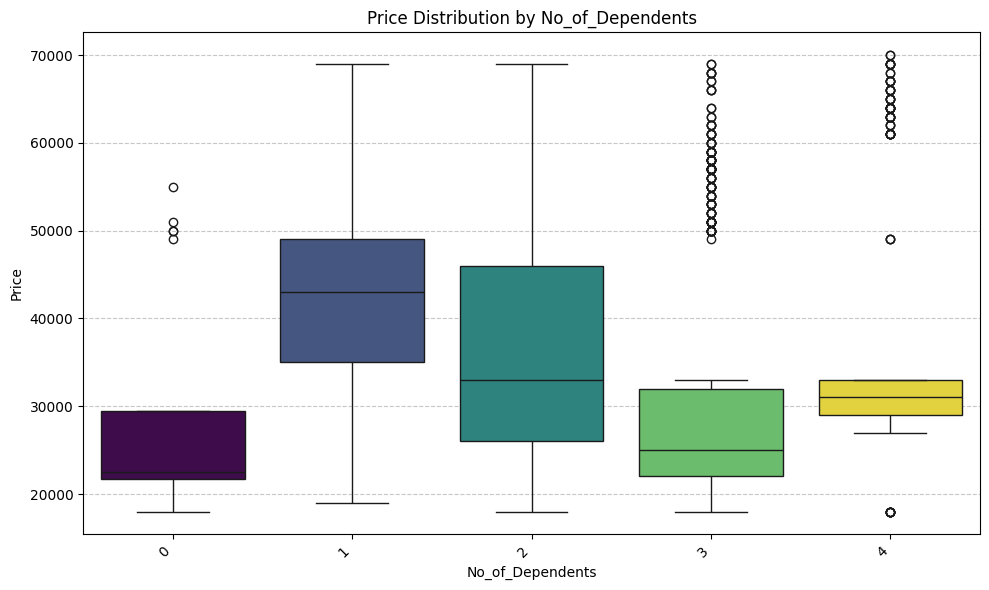

In [ ]:
categorical_cols_for_price_analysis = ['Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan', 'House_loan', 'Partner_working', 'No_of_Dependents']

for col in categorical_cols_for_price_analysis:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=col, y='Price', hue=col, palette='viridis', legend=False)
    plt.title(f'Price Distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Summary of Price Distribution by No_of_Dependents

Based on the box plot visualizing the distribution of 'Price' across different 'No_of_Dependents' categories, and consistent with the weak correlation (0.13) observed earlier, here are the consolidated observations:

*   **Similar Price Ranges**: The price ranges for automobiles appear to be relatively consistent across different numbers of dependents (0, 1, 2, 3, 4). There isn't a significant upward or downward trend in the overall price range as the number of dependents changes.
*   **Median Price Stability**: The median car price does not show a clear or substantial variation with the increase or decrease in the number of dependents. This indicates that the number of dependents alone is not a primary driver for purchasing significantly more expensive or cheaper cars.
*   **Spread of Prices**: While the median prices are similar, the box plots show a similar spread of prices across most dependent categories, suggesting that individuals with various numbers of dependents buy cars from a wide price spectrum.
*   **No Strong Influence**: The data suggests that `No_of_Dependents` has a minimal influence on the price of the purchased automobile. Other factors, such as individual or total salary and age, are much stronger indicators of car price.

In summary, while the number of dependents might influence car make preference volume (as seen in earlier analysis, with 2-3 dependents showing higher purchase counts), it does not significantly influence the *price* of the cars purchased. Customers across all dependent categories tend to purchase cars within similar price distributions.

## Car Make Preferences by Demographics

Generate count plots to explore the relationship between 'Make' and categorical variables such as 'Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan', 'House_loan', 'Partner_working' and 'No_of_Dependents'. This will help identify demographic preferences for different car types.


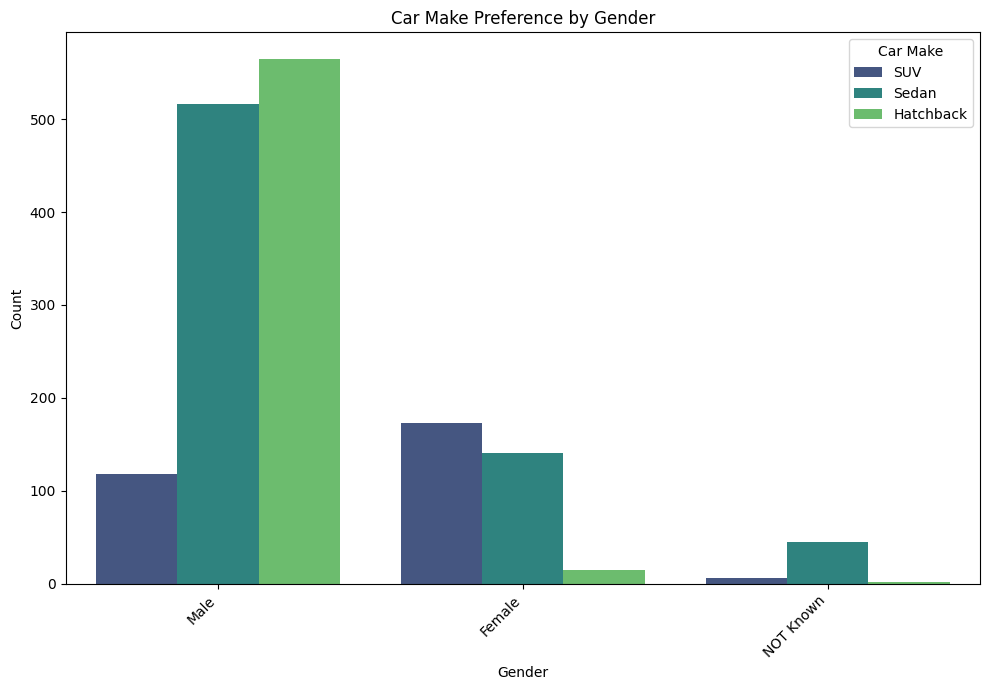

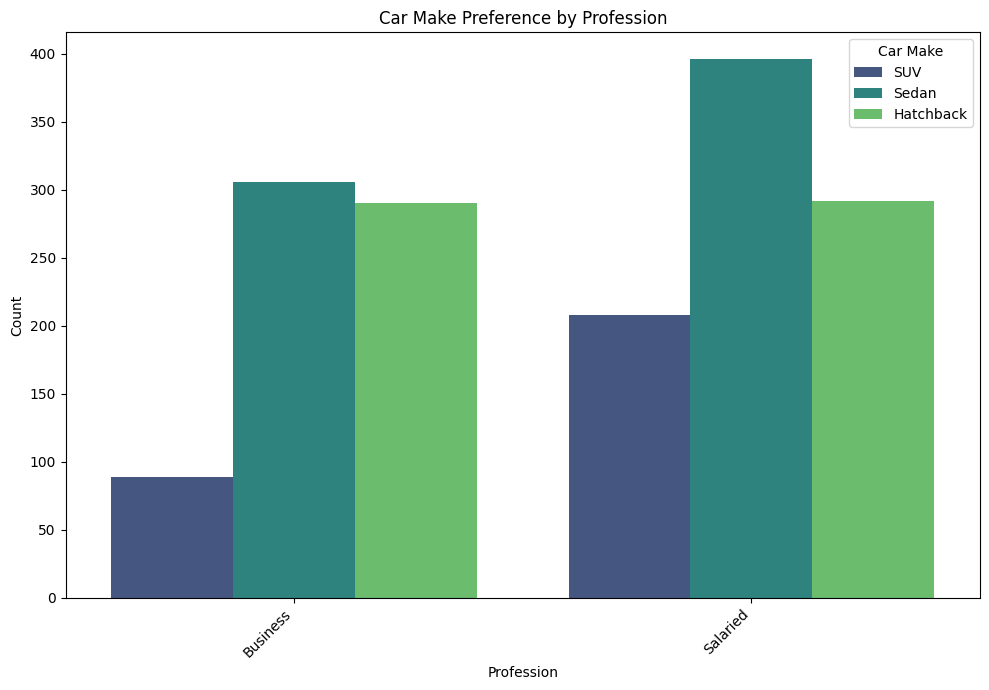

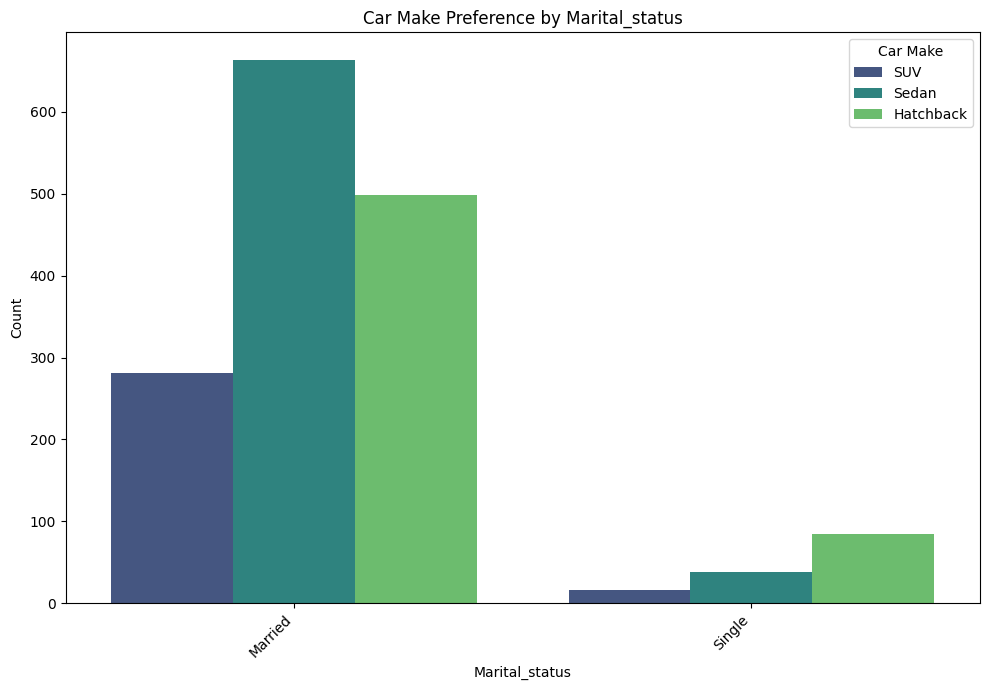

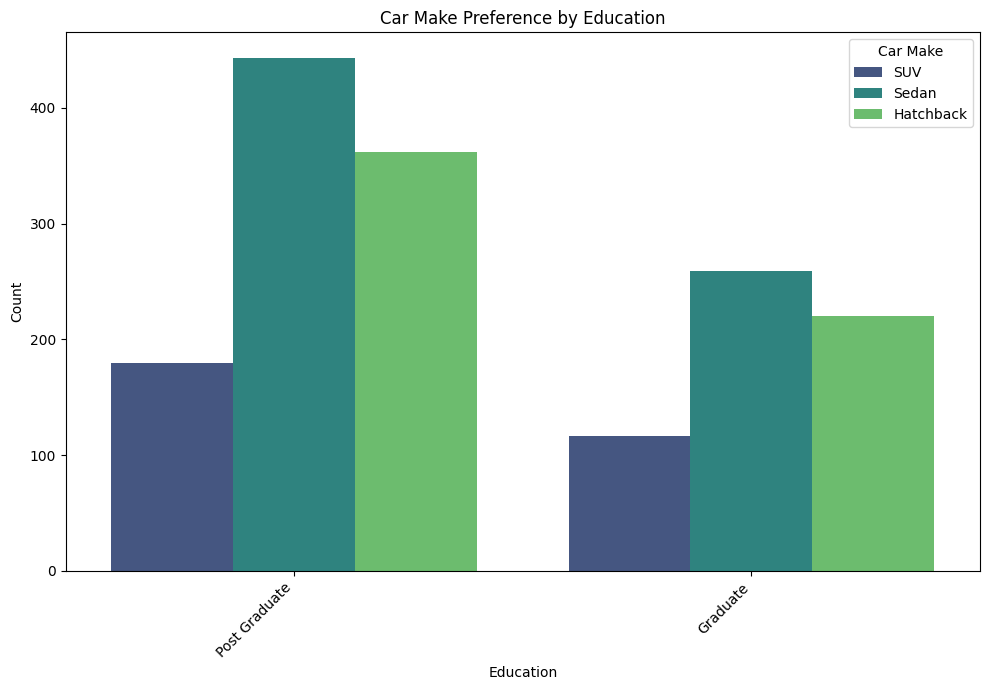

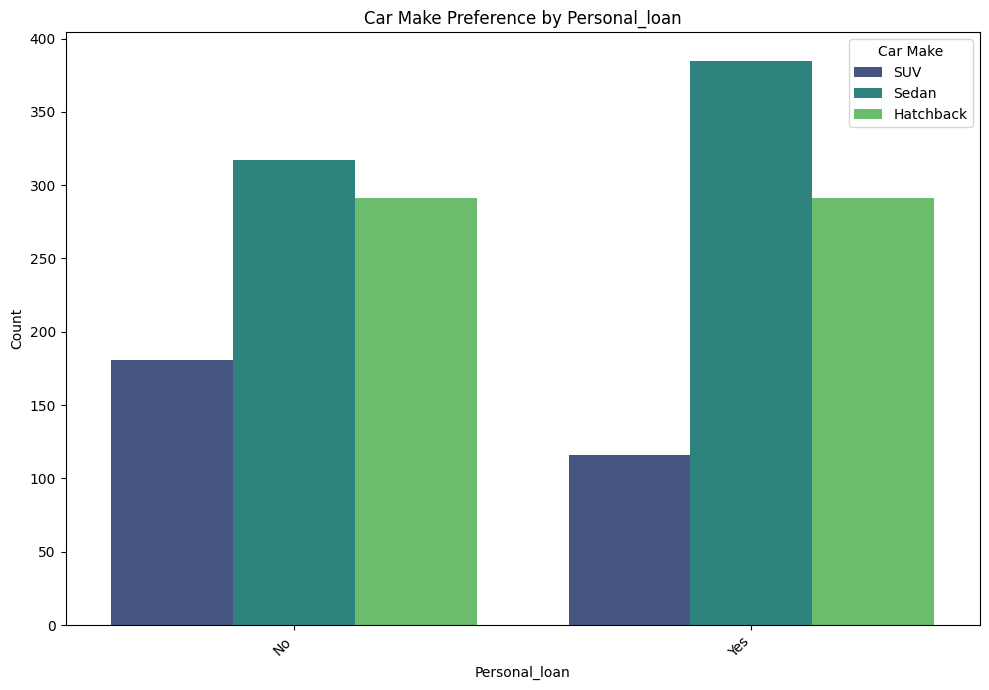

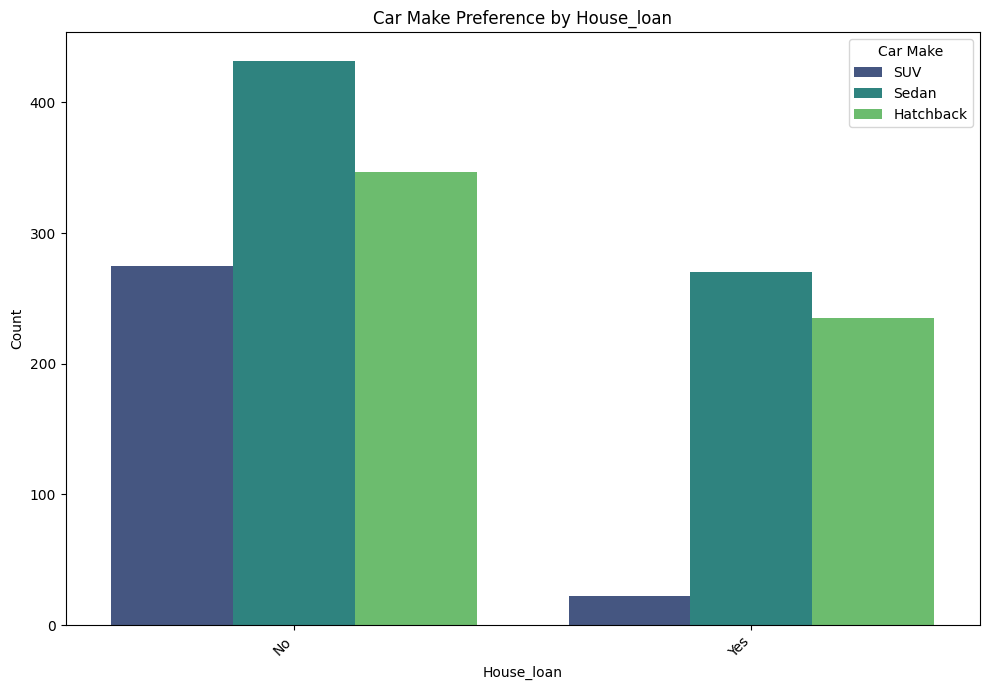

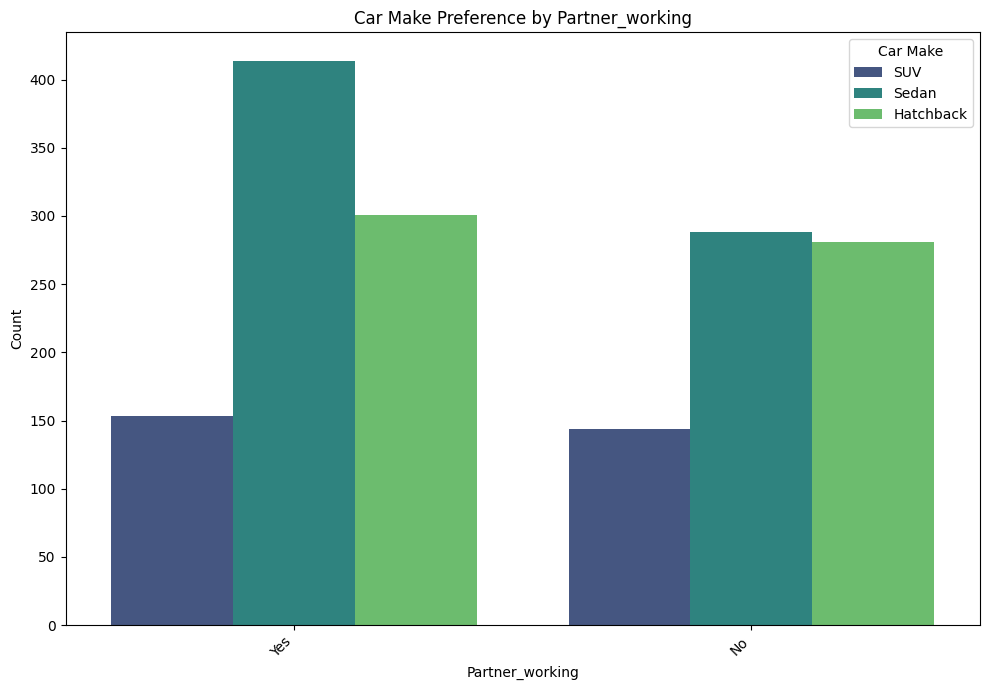

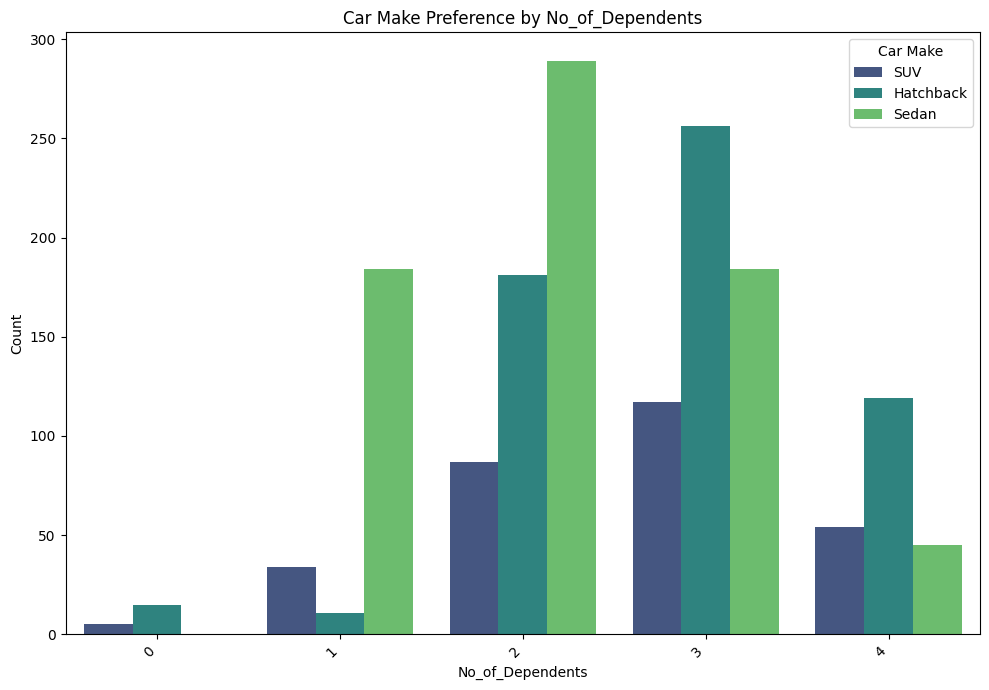

In [ ]:
demograph_financial_cols = ['Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan', 'House_loan', 'Partner_working', 'No_of_Dependents']

for col in demograph_financial_cols:
    plt.figure(figsize=(10, 7))
    sns.countplot(data=df, x=col, hue='Make', palette='viridis')
    plt.title(f'Car Make Preference by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Car Make')
    plt.tight_layout()
    plt.show()

## Summary of Car Make Preferences by Demographics

Based on the count plots visualizing car make preferences across different demographic and financial categories, here are the consolidated observations:

### Gender:
- **Male vs. Female**: While males generally purchase more cars overall, 'Sedan' and 'Hatchback' are preferred by both genders, with 'SUV' being the least preferred. The proportions of car types seem similar across genders, though males show a slightly higher absolute count for all makes.

### Profession:
- **Salaried vs. Business**: 'Salaried' individuals show a strong preference for 'Sedan' and 'Hatchback', with 'SUV' being less popular. 'Business' professionals also lean towards 'Sedan' and 'Hatchback', but their overall purchase counts for each 'Make' are slightly lower than 'Salaried' individuals.

### Marital_status:
- **Married vs. Single**: 'Married' individuals overwhelmingly purchase more cars across all categories, reflecting their larger population in the dataset. 'Sedan' and 'Hatchback' remain the top choices for both married and single individuals, with 'SUV' being less common.

### Education:
- **Post Graduate vs. Graduate**: 'Post Graduate' individuals show a higher volume of purchases across all car makes, with 'Sedan' and 'Hatchback' being the most popular. 'Graduate' individuals follow a similar preference pattern but with fewer overall purchases.

### Personal_loan:
- **With vs. Without Personal Loan**: Individuals with and without personal loans show a similar distribution of car make preferences. 'Sedan' and 'Hatchback' are dominant, and 'SUV' is less popular, regardless of personal loan status. The total number of purchases is almost evenly split between these two groups.

### House_loan:
- **With vs. Without House Loan**: Customers without a house loan purchase more cars in general, and their preferences for 'Sedan' and 'Hatchback' are notably higher than 'SUV'. Customers with a house loan follow a similar trend but with fewer purchases overall.

### Partner_working:
- **Partner Working (Yes/No)**: Individuals with working partners ('Yes') tend to purchase more cars across all makes, maintaining the preference for 'Sedan' and 'Hatchback'. Individuals without working partners ('No') show fewer purchases but maintain the same relative preference order among car types.

### No_of_dependants:
*   **Overall Preference**: 'Sedan' and 'Hatchback' are consistently more popular than 'SUV' across all categories of 'No_of_Dependents'.
*   **Distribution**: Most individuals have 2 or 3 dependents, and within these groups, Sedans and Hatchbacks are the dominant choices. SUVs are purchased significantly less, even in the segments with higher numbers of dependents.
*   **Higher Dependents**: Individuals with 2 or 3 dependents show the highest absolute counts for car purchases across all makes, consistent with the overall distribution of 'No_of_Dependents'.
*   **Minimal Impact on Relative Preference**: The number of dependents does not drastically alter the *relative* preference between car types (Sedan > Hatchback > SUV). Instead, it primarily influences the *volume* of purchases within each car make, mirroring the distribution of dependents in the dataset.

## Summary of Bivariate Analysis

### Numerical Variable Correlations:
- **Price and Total_salary**: A strong positive correlation (0.76) suggests that customers with higher combined salaries tend to purchase more expensive cars.
- **Price and Salary**: A very strong positive correlation (0.83) indicates that the individual's salary is a major determinant of car price.
- **Price and Age**: A strong positive correlation (0.79) implies that older individuals tend to buy more expensive cars.
- **Price and Partner_salary**: A moderate positive correlation (0.42) indicates that a partner's salary also contributes to the car purchase price, but less significantly than the individual's salary.

### Price Distribution by Car Make:
- **SUV**: SUVs generally have the highest price range and median price, indicating they are premium vehicles.
- **Sedan**: Sedans show a moderate price range, falling between SUVs and Hatchbacks.
- **Hatchback**: Hatchbacks have the lowest price range and median price, suggesting they are the most budget-friendly option.

### Price Distribution by Demographic and Financial Categories:
- **Gender**: Males tend to purchase slightly more expensive cars on average than females, though both genders purchase across a wide price range.
- **Profession**: Business professionals tend to buy more expensive cars compared to salaried individuals.
- **Marital Status**: Married individuals purchase a broader and generally higher price range of cars than single individuals.
- **Education**: Post-graduates tend to purchase more expensive cars than graduates.
- **Personal/House Loan**: Individuals with personal loans or house loans show varied price distributions, but no clear pattern of consistently buying more expensive or cheaper cars compared to those without loans.
- **Partner Working**: Individuals with working partners tend to purchase slightly more expensive cars, aligning with the higher total income.
- **No of dependants**: While the median prices are similar, the box plots show a similar spread of prices across most dependent categories, suggesting that individuals with various numbers of dependents buy cars from a wide price spectrum.The data suggests that No_of_Dependents has a minimal influence on the price of the purchased automobile. Other factors, such as individual or total salary and age, are much stronger indicators of car price.

### Car Make Preferences by Demographics:
- **Overall Preference**: 'Sedan' and 'Hatchback' are consistently more popular than 'SUV' across almost all demographic and financial categories.
- **Gender**: Both males and females prefer Sedans and Hatchbacks, with males having higher absolute counts across all makes.
- **Profession**: Salaried and Business professionals both prefer Sedans and Hatchbacks, with Salaried individuals purchasing more overall.
- **Marital Status & Education**: Married individuals and Post Graduates show higher purchasing volumes across all makes, maintaining the preference for Sedans and Hatchbacks.
- **Loan Status & Partner Working**: The preference for Sedans and Hatchbacks remains dominant regardless of personal loan status, house loan status, or whether a partner is working. Individuals without house loans and those with working partners show higher overall purchase counts.

### Key Takeaways:
- **Targeting based on Income**: Salary, total salary, and age are strong indicators of car price.
- **Car Type Marketing**: Emphasize the value proposition of Sedans and Hatchbacks for the broader market, while highlighting the premium aspects of SUVs for higher-income segments.
- **Demographic Segmentation**: Consider gender, marital status, profession, and education for targeted campaigns, as they show varying purchasing power and make preferences.
- **Loan Status**: While loan status doesn't drastically change make preference, it can be a factor in affordability and messaging.
- **Partner Income**: Partner's salary contributes to total income, influencing the car price, indicating couples as a potential target segment for higher-end vehicles.

## Total Salary Distribution by Car Make and Demographics

Produce box plots to visualize how 'Total_salary' is distributed across different 'Make' types and key demographic/financial categories like 'Profession', 'Education', and 'Marital_status'. This analysis will shed light on the purchasing power of different customer segments and their car choices.


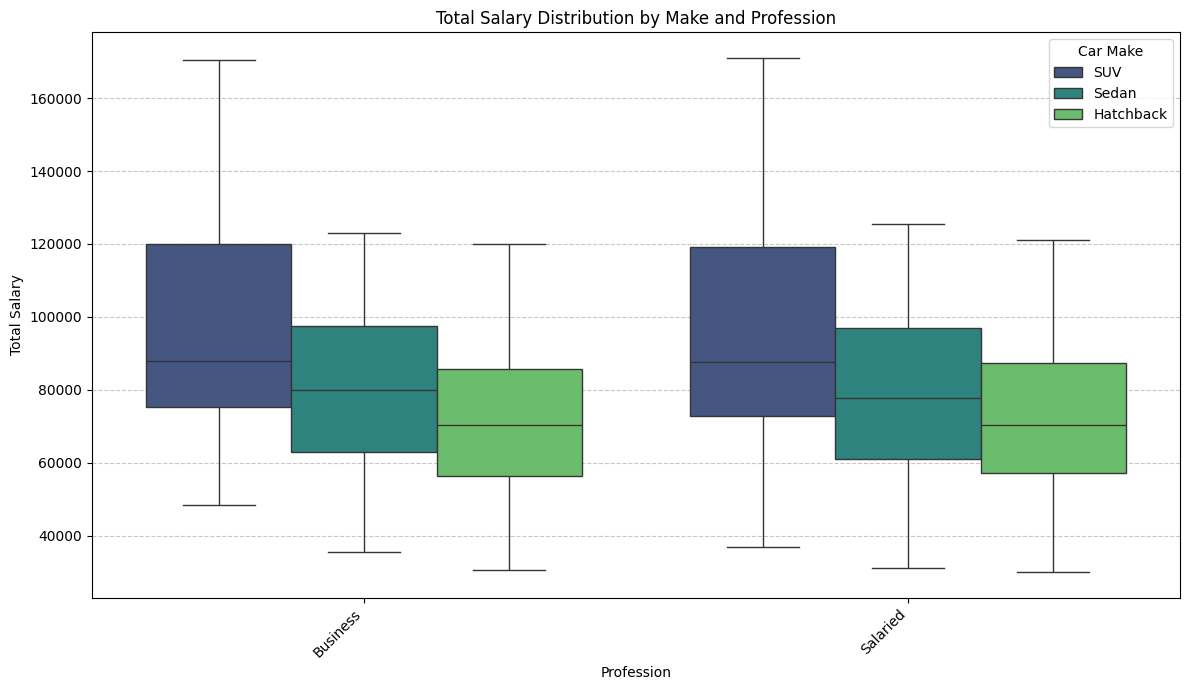

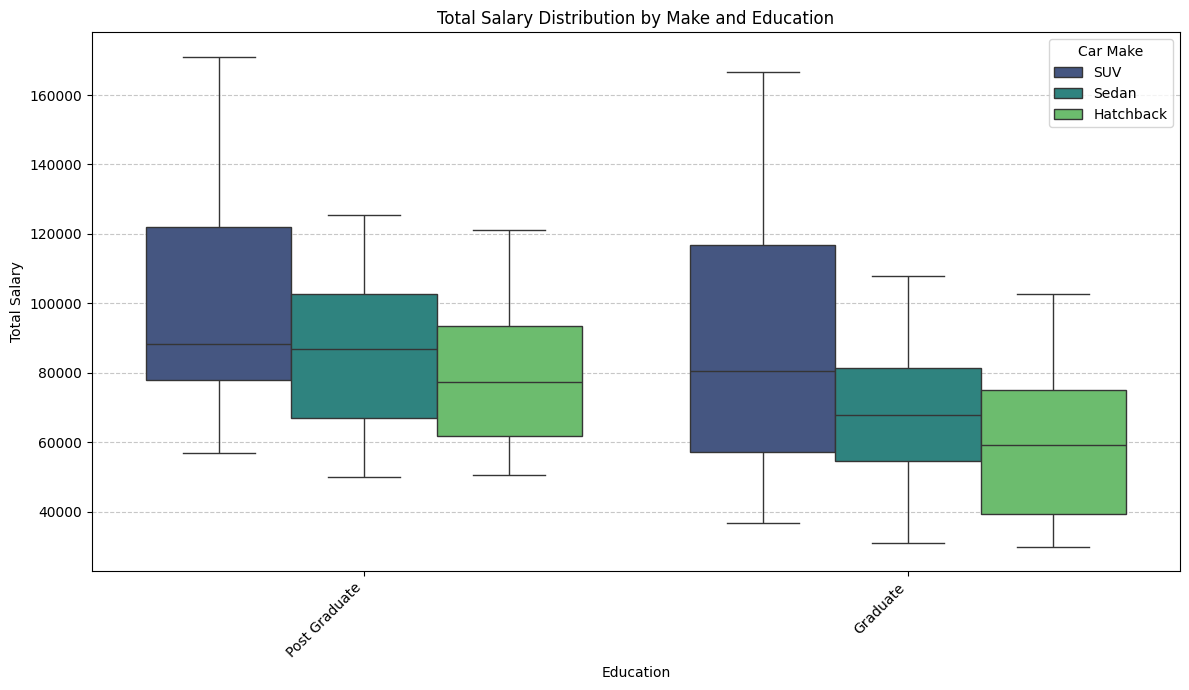

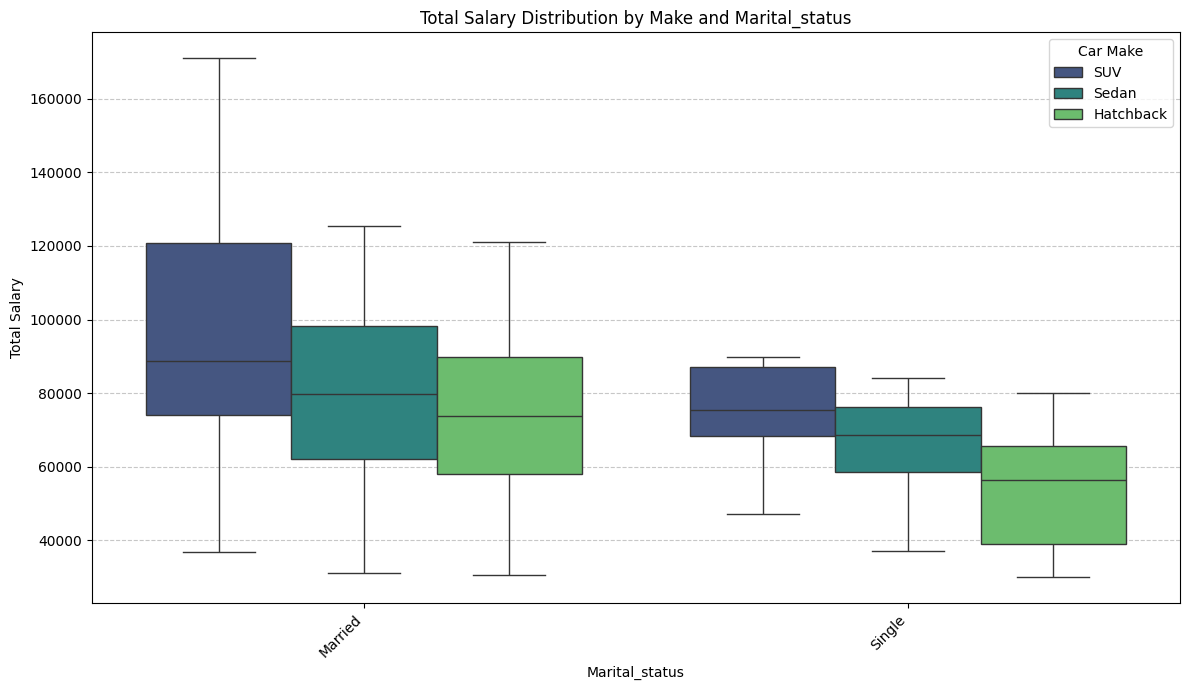

In [19]:
demographic_financial_categories = ['Profession', 'Education', 'Marital_status']

for category in demographic_financial_categories:
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df, x=category, y='Total_salary', hue='Make', palette='viridis')
    plt.title(f'Total Salary Distribution by Make and {category}')
    plt.xlabel(category)
    plt.ylabel('Total Salary')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Car Make')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Summary of Total Salary Distribution by Car Make and Demographics

Based on the box plots visualizing 'Total_salary' distribution across different 'Make' types and key demographic/financial categories, here are the consolidated observations:

### Profession:
-   **Salaried vs. Business**: For both 'Salaried' and 'Business' professionals, 'SUV' buyers generally have higher 'Total_salary' distributions compared to 'Sedan' and 'Hatchback' buyers. 'Business' professionals tend to have a wider range of 'Total_salary', especially for SUVs, suggesting more variability in their income.
-   **Median Total Salary**: Across all car makes, 'Business' professionals often show a slightly higher median 'Total_salary' than 'Salaried' individuals for a given car make, particularly for SUVs.

### Education:
-   **Post Graduate vs. Graduate**: Individuals with 'Post Graduate' education generally exhibit higher 'Total_salary' distributions across all car makes compared to 'Graduate' individuals. This suggests that higher education correlates with higher purchasing power.
-   **SUV vs. Other Makes**: Within both education groups, customers purchasing 'SUVs' typically have the highest median 'Total_salary', followed by 'Sedans' and then 'Hatchbacks'. This reinforces the idea that SUVs are associated with higher income brackets.

### Marital_status:
-   **Married vs. Single**: 'Married' individuals, especially those purchasing 'SUVs' and 'Sedans', tend to have higher 'Total_salary' distributions and wider ranges compared to 'Single' individuals. This is likely due to combined household incomes.
-   **Income Hierarchy by Make**: For both 'Married' and 'Single' categories, the 'Total_salary' distribution follows a clear pattern: SUV buyers have the highest incomes, followed by Sedan buyers, and then Hatchback buyers. This trend is consistent regardless of marital status.

### General Observations Across Categories:
-   **Income-Make Correlation**: Across all demographic and financial categories analyzed, there is a consistent trend: individuals purchasing 'SUVs' generally have the highest 'Total_salary', followed by those buying 'Sedans', and then 'Hatchbacks'. This clearly indicates a strong positive relationship between total household income and the price/type of car purchased.
-   **Purchasing Power Differences**: Demographic factors like 'Profession', 'Education', and 'Marital_status' influence the overall 'Total_salary' levels, which in turn impacts the type of car they can afford or prefer. Higher income segments (e.g., Business professionals, Post Graduates, Married individuals) tend to be more represented in the higher-priced car segments like SUVs.

## Consolidated Summary of Bivariate Analysis Insights

This section consolidates the findings from the bivariate analysis, including correlations between numerical variables, price distributions by car make and various demographic/financial categories, car make preferences by demographics, and total salary distributions by car make and demographics. These insights will inform actionable strategies for improving marketing campaigns.

### Key Findings:

1.  **Strong Determinants of Car Price:**
    *   **Individual Salary (0.83) and Total Salary (0.76)** are the strongest positive correlates with 'Price', indicating that higher income directly leads to the purchase of more expensive cars. This relationship is more pronounced than 'Partner_salary' (0.42).
    *   **Age (0.79)** also shows a strong positive correlation with car price, suggesting older individuals tend to buy higher-priced vehicles.
    
2.  **Car Make and Price Segmentation:**
    *   **SUVs** command the highest price range and median price, positioning them as premium vehicles.
    *   **Sedans** occupy a moderate price bracket, appealing to a broad segment.
    *   **Hatchbacks** are the most budget-friendly option, with the lowest price range and median price.

3.  **Price Sensitivity Across Demographics:**
    *   **Gender:** Males, on average, tend to purchase slightly more expensive cars than females, although both genders exhibit diverse purchasing power.
    *   **Profession:** 'Business' professionals generally opt for more expensive cars than 'Salaried' individuals, reflecting potentially higher disposable incomes or different professional needs.
    *   **Marital Status:** 'Married' individuals tend to purchase cars within a broader and generally higher price range compared to 'Single' individuals, likely due to combined household incomes and family needs.
    *   **Education:** 'Post Graduates' show a tendency to purchase more expensive cars than 'Graduates'.
    *   **Loan Status & Partner Working:** While not consistently indicating higher-priced purchases, individuals with working partners tend to purchase slightly more expensive cars, aligning with their higher combined 'Total_salary'. Loan status (personal or house) does not show a clear pattern of driving price up or down significantly.

4.  **Car Make Preferences by Demographics:**
    *   **Overall Preference:** 'Sedan' and 'Hatchback' consistently outperform 'SUV' in popularity across almost all demographic segments.
    *   **Gender, Profession, Marital Status, Education, Loan Status, Partner Working:** The general preference for Sedans and Hatchbacks over SUVs holds true across all these categories. Differences are primarily in absolute purchase volumes rather than relative preference among car types. For instance, 'Married' individuals and 'Post Graduates' show higher overall purchase volumes for all car makes.

5.  **Total Salary Distribution by Car Make and Demographics:**
    *   **Profession:** For both 'Salaried' and 'Business' professionals, customers purchasing SUVs generally have higher 'Total_salary' ranges compared to those buying Sedans or Hatchbacks. Business professionals, in particular, show a higher ceiling for 'Total_salary' when purchasing SUVs.
    *   **Education:** 'Post Graduates' buying SUVs tend to have a higher 'Total_salary' range than 'Graduates' buying SUVs. The median 'Total_salary' for 'Post Graduates' across all car makes is typically higher than for 'Graduates'.
    *   **Marital Status:** 'Married' individuals who buy SUVs generally exhibit a higher 'Total_salary' compared to 'Single' individuals buying SUVs. This reinforces the idea that combined household income supports higher-value purchases.
    *   This analysis confirms that higher 'Total_salary' is indeed a characteristic of customers who purchase more expensive car makes, especially SUVs, and this pattern is consistent across different professions, education levels, and marital statuses.

### Actionable Strategies for Improving Marketing Campaigns:

1.  **Income-Based Targeting & Tiered Marketing:**
    *   **High-Income (Higher Salary, Total Salary, Older Age):** Target these segments with premium SUV models. Marketing messages should emphasize luxury, performance, advanced features, and safety. Utilize channels frequented by affluent and older demographics.
    *   **Mid-Income (Moderate Salary, Total Salary):** Focus on Sedans, highlighting a balance of comfort, style, fuel efficiency, and technology. This segment is broad and can be reached through diverse channels.
    *   **Budget-Conscious (Lower Salary, Younger Age):** Promote Hatchbacks with an emphasis on affordability, practicality, fuel economy, and urban maneuverability.

2.  **Demographic-Specific Messaging:**
    *   **Married Couples/Families:** Tailor campaigns for Sedans and larger Hatchbacks, emphasizing family-friendly features, space, and safety. Highlight the role of combined income in purchase decisions.
    *   **Business Professionals:** Focus on premium Sedans and potentially SUVs for their perceived status, comfort for long drives, and advanced connectivity. Highlight durability and professionalism.
    *   **Post Graduates:** Market towards sophisticated technology, environmental considerations, and performance features, as they tend to have higher purchasing power and potentially different values.
    *   **Gender:** While preferences are similar, acknowledge males' higher purchase volumes by ensuring broad reach.

3.  **Leverage Partner Income:**
    *   Marketing efforts for higher-priced vehicles should consider the 'Total_salary' aspect, implying that campaigns could be directed towards households rather than just individuals for mid-to-high range cars. Messages can appeal to shared family goals or combined financial planning.

4.  **Strategic Positioning of SUVs:**
    *   Given the strong preference for Sedans and Hatchbacks, SUV marketing needs to be highly targeted. Instead of broad campaigns, focus on segments with demonstrably higher 'Total_salary', particularly 'Business' professionals, 'Married' individuals, and 'Post Graduates', positioning SUVs as aspirational or utilitarian for specific needs .

5.  **Loan Status as an Affordability Signal (Not a Preference Driver):**
    *   Loan status doesn't dictate car type preference but can inform financing offers and affordability messaging.

By segmenting customers based on their income, age, profession, education, and marital status, Austo Automobiles can develop more precise and effective marketing campaigns that resonate with specific customer demands and preferences, ultimately improving campaign efficiency and customer experience.

# Questions From Company - Answers

# 1. Do men tend to prefer SUVs more compared to women?

In [20]:
df[df['Make'] == 'SUV']['Gender'].value_counts()

,count
Gender,
Female,173
Male,118
NOT Known,6


Based on the bivariate analysis of car make preferences by demographics, we observed the following regarding gender:

No, men do not tend to prefer SUVs more compared to women in terms of proportionate preference.

The analysis indicated that the proportions of car types preferred are similar across genders, with males only showing a slightly higher absolute count for all car makes, not a disproportionate preference for SUVs.

# 2.What is the likelihood of a salaried person buying a Sedan?

In [21]:
# Calculate the number of salaried individuals
salaried_count = df[df['Profession'] == 'Salaried'].shape[0]

# Calculate the number of salaried individuals who bought a Sedan
salaried_sedan_count = df[(df['Profession'] == 'Salaried') & (df['Make'] == 'Sedan')].shape[0]

# Calculate the likelihood
if salaried_count > 0:
    likelihood = (salaried_sedan_count / salaried_count) * 100
    print(f"The likelihood of a salaried person buying a Sedan is: {likelihood:.2f}%")
else:
    print("There are no salaried individuals in the dataset.")

The likelihood of a salaried person buying a Sedan is: 44.20%


The likelihood of a salaried person buying a Sedan is 44.20%. This means that nearly half of the salaried individuals in the dataset tend to purchase Sedans.

# 3.What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?


Generate actual purchase data for 'Salaried' 'Male' individuals regarding 'SUV's versus 'Sedan's.

In [22]:
# Filter for 'Salaried' and 'Male' individuals
salaried_male_df = df[(df['Profession'] == 'Salaried') & (df['Gender'] == 'Male')]

# Get the counts of 'Make' for this segment
make_counts = salaried_male_df['Make'].value_counts()

print("Car Make preferences for Salaried Male individuals:")
print(make_counts)

Car Make preferences for Salaried Male individuals:
Make
Sedan        279
Hatchback    276
SUV           85
Name: count, dtype: int64


Based on the data for 'Salaried Male' individuals:

Sedan: 279 purchases
Hatchback: 276 purchases
SUV: 85 purchases
This data does not support Sheldon Cooper's claim that a salaried male is an easier target for an SUV sale over a Sedan sale. On the contrary, 'Salaried Male' individuals show a significantly higher preference for Sedans (279 purchases) and Hatchbacks (276 purchases) compared to SUVs (85 purchases).

# 4. How does the amount spent on purchasing automobiles vary by gender?


create a box plot showing the distribution of car 'Price' for males and females, and also do descriptive statistics.

Descriptive Statistics of Price by Gender:


,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,329.0,47705.167173,11244.836378,20000.0,38000.0,49000.0,55000.0,69000.0
Male,1199.0,32817.347790,12299.239195,18000.0,24000.0,29000.0,37500.0,70000.0
NOT Known,53.0,23339.622642,10308.591257,18000.0,18000.0,18000.0,19000.0,50000.0


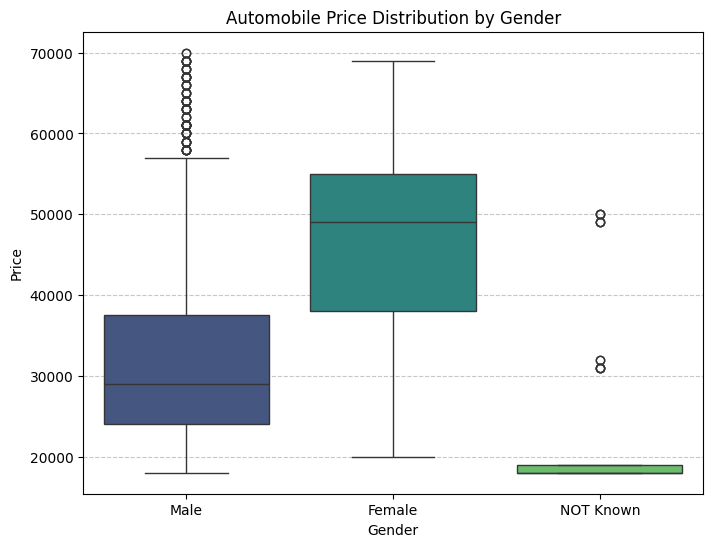

In [23]:
# Descriptive statistics of 'Price' by 'Gender'
print("Descriptive Statistics of Price by Gender:")
display(df.groupby('Gender')['Price'].describe())

# Create a box plot to visualize 'Price' distribution by 'Gender'
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Gender', y='Price', hue='Gender', palette='viridis', legend=False)
plt.title('Automobile Price Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based on the previous analysis, here's how the amount spent on purchasing automobiles varies by gender:

**Observations:**

**Female:**

Mean Price: Females tend to purchase significantly more expensive cars on average, with a mean price of approximately $47,705.16.

Median Price: The median price for cars purchased by females is $49,000, indicating that half of their purchases are above this amount.

Distribution: Their purchases span a range from  25,000to 69,000. The distribution appears relatively symmetric around the median or slightly left-skewed, indicating a concentration of purchases at higher price points within their range.

**Male:**

Mean Price: Males, who constitute a much larger group, purchase cars with a lower average price of approximately $32,416.18.

Median Price: The median price for cars purchased by males is $29,000.

Distribution: Their purchases range from  18,000to 70,000. The distribution is right-skewed (mean > median), suggesting a tail extending to higher prices, implying some males purchase very expensive cars, but the majority are concentrated at lower price points compared to females.

**NOT Known:**

Mean Price: The 'NOT Known' category shows the lowest average expenditure at approximately $26,320.75.

 Median Price: The median price for this group is $25,000.
Distribution: Their price range is from  18,000to 47,000.

**Key Takeaways:**

**Gender-based Spending:** Females, despite being a smaller group in the dataset, generally purchase automobiles that are considerably more expensive than those purchased by males and the 'NOT Known' category, as indicated by both mean and median prices.

**Price Range Overlap:** While average spending differs, both males and females purchase across a wide range of prices, with maximum purchases reaching similar levels ( 69,000 for females, 70,000 for males). However, the central tendency of their spending is distinct.

# 5. How much money was spent on purchasing automobiles by individuals who took a personal loan?

To determine the total amount spent on automobiles by individuals who took a personal loan, Calculate the sum of 'Price' for all customers who have a 'Personal_loan'. calculate the total money spent by individuals who took a personal loan.

In [30]:
# Filter for individuals who took a personal loan
personal_loan_buyers = df[df['Personal_loan'] == 'Yes']

# Calculate the total money spent on purchasing automobiles by these individuals
total_spent_by_personal_loan_takers = personal_loan_buyers['Price'].sum()

print(f"Total money spent on automobiles by individuals who took a personal loan: ${total_spent_by_personal_loan_takers:,.2f}")

Total money spent on automobiles by individuals who took a personal loan: $27,290,000.00


The total money spent on automobiles by individuals who took a personal loan is $27,290,000.00.

# 6. How does having a working partner influence the purchase of higher-priced cars?

Based on the bivariate analysis, here's how having a working partner influences the purchase of higher-priced cars:

Higher Total Income: Individuals with a working partner generally have a higher 'Total_salary'. This increased household income allows them to afford and consequently purchase more expensive cars.
Tendency Towards More Expensive Cars: The analysis showed that individuals with working partners tend to purchase slightly more expensive cars on average. This aligns with the understanding that greater financial capacity leads to higher-value purchases.
Impact on Car Type: While the general preference for Sedans and Hatchbacks remains, the higher 'Total_salary' associated with a working partner means these households are more likely to be able to afford and therefore potentially choose higher-end models within any car make, or even transition to premium segments like SUVs if other demographic factors align. The Partner_salary itself shows a moderate positive correlation with 'Price' (0.42), further supporting this.
In essence, having a working partner contributes to a higher combined household income, which acts as a significant enabler for the purchase of more expensive automobiles.

## Actionable Insights & Recommendations:


1.  **Which numerical variables have strong linear relationships with 'Price'?**
    'Salary' (0.83), 'Age' (0.79), and 'Total_salary' (0.76) show strong positive correlations with 'Price'. 'Partner_salary' has a moderate positive correlation (0.42).

2.  **Do certain car types ('Sedan', 'Hatchback', 'SUV') associate with distinct price ranges?**
    Yes, 'SUV's generally have the highest price range and median price, followed by 'Sedan's in the moderate range, and 'Hatchback's as the most budget-friendly option with the lowest price range and median price.

3.  **Do specific customer segments tend to buy more expensive or cheaper cars?**
    *   'Business' professionals and 'Married' individuals tend to purchase more expensive cars compared to 'Salaried' and 'Single' individuals, respectively.
    *   'Post Graduates' tend to buy more expensive cars than 'Graduates'.
    *   Males, on average, tend to purchase slightly more expensive cars than females. Females, despite being a smaller group in the dataset, generally purchase automobiles that are considerably more expensive than those purchased by males
    *   Individuals with working partners also tend to purchase slightly more expensive cars due to higher combined incomes.

4.  **Are there demographic preferences for different car types?**
    Yes, 'Sedan' and 'Hatchback' are consistently more popular than 'SUV' across almost all demographic and financial categories, despite 'SUV's being associated with higher income.

### Data Analysis Key Findings

*   **Strong Predictors of Car Price**: The individual's 'Salary' (0.83), 'Age' (0.79), and 'Total_salary' (0.76) exhibit strong positive correlations with the car's 'Price', indicating that higher income and older age are associated with more expensive vehicle purchases.
*   **Car Make Price Hierarchy**: 'SUVs' are positioned as premium vehicles with the highest median price and price range, while 'Sedans' fall in a moderate price bracket, and 'Hatchbacks' are the most affordable option.
*   **Income Influences Car Type Choice**: Across all demographic categories analyzed, individuals purchasing 'SUVs' consistently demonstrate the highest 'Total_salary' distributions, followed by 'Sedan' buyers, and then 'Hatchback' buyers, reinforcing the link between higher income and more expensive car types.
*   **Demographic Impact on Purchasing Power**: 'Business' professionals, 'Post Graduates', and 'Married' individuals generally show higher 'Total_salary' distributions and tend to purchase more expensive cars, especially 'SUVs', compared to their respective counterparts ('Salaried', 'Graduates', 'Single').
*   **Consistent Car Make Preferences**: Despite 'SUVs' being associated with higher incomes, 'Sedan' and 'Hatchback' models are consistently preferred by a wider range of customers across various demographic and financial segments (Gender, Profession, Marital Status, Education, Loan Status, Partner Working).

### Insights or Next Steps

*   **Implement Income-Based Tiered Marketing**: Tailor marketing campaigns based on income levels and age, promoting premium 'SUV' models to high-income, older demographics, 'Sedans' to mid-income segments, and 'Hatchbacks' to budget-conscious, younger buyers.
*   **Strategic Positioning for SUVs**: Given the general preference for 'Sedans' and 'Hatchbacks', 'SUV' marketing should be highly targeted towards higher-income segments like 'Business' professionals, 'Post Graduates', and 'Married' individuals, highlighting features that appeal to their specific needs and aspirations (e.g., status, family utility, advanced technology).
